In [2]:
# ==========================================
# CELDA 1 - IMPORTS Y CONFIGURACIÓN GENERAL
# ==========================================

import pandas as pd
from pathlib import Path

# =========================
# CIC - múltiples CSV
# =========================
ruta_cic_folder = Path("/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosCIC/DictionaryBruteForce")

csv_files_cic = sorted(ruta_cic_folder.glob("*.csv"))

print(f"[CIC] Nº archivos encontrados: {len(csv_files_cic)}")

dfs_cic = []
for file in csv_files_cic:
    df_temp = pd.read_csv(file, low_memory=False)
    df_temp["archivo_origen"] = file.name
    dfs_cic.append(df_temp)

df_cic = pd.concat(dfs_cic, ignore_index=True)

print("[CIC] Shape final:", df_cic.shape)

print("Ruta CIC   :", ruta_cic_folder)
print("Existe CIC?   ", ruta_cic_folder.exists())

# =========================
# NEMEA - un único CSV
# =========================
ruta_nemea = Path("/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosNEMEA/DictionaryBruteForce/DictionaryBruteForce_Nemea.csv")

df_nemea = pd.read_csv(ruta_nemea, low_memory=False)

print("[NEMEA] Shape:", df_nemea.shape)


print("Ruta NEMEA :", ruta_nemea)
print("Existe NEMEA? ", ruta_nemea.exists())

[CIC] Nº archivos encontrados: 1
[CIC] Shape final: (8554, 85)
Ruta CIC   : /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosCIC/DictionaryBruteForce
Existe CIC?    True
[NEMEA] Shape: (7877, 204)
Ruta NEMEA : /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosNEMEA/DictionaryBruteForce/DictionaryBruteForce_Nemea.csv
Existe NEMEA?  True


In [3]:
# ==========================================
# CELDA 2 - MOSTRAR TODAS LAS COLUMNAS
# ==========================================

print("COLUMNAS CIC:")
for i, col in enumerate(df_cic.columns, start=1):
    print(f"{i:03d}. {col}")

print("\n" + "="*80 + "\n")

print("COLUMNAS NEMEA:")
for i, col in enumerate(df_nemea.columns, start=1):
    print(f"{i:03d}. {col}")

columnas_cic = df_cic.columns.tolist()
columnas_nemea = df_nemea.columns.tolist()

print("Nº columnas CIC:", len(columnas_cic))
print("Nº columnas NEMEA:", len(columnas_nemea))


COLUMNAS CIC:
001. Flow ID
002. Src IP
003. Src Port
004. Dst IP
005. Dst Port
006. Protocol
007. Timestamp
008. Flow Duration
009. Total Fwd Packet
010. Total Bwd packets
011. Total Length of Fwd Packet
012. Total Length of Bwd Packet
013. Fwd Packet Length Max
014. Fwd Packet Length Min
015. Fwd Packet Length Mean
016. Fwd Packet Length Std
017. Bwd Packet Length Max
018. Bwd Packet Length Min
019. Bwd Packet Length Mean
020. Bwd Packet Length Std
021. Flow Bytes/s
022. Flow Packets/s
023. Flow IAT Mean
024. Flow IAT Std
025. Flow IAT Max
026. Flow IAT Min
027. Fwd IAT Total
028. Fwd IAT Mean
029. Fwd IAT Std
030. Fwd IAT Max
031. Fwd IAT Min
032. Bwd IAT Total
033. Bwd IAT Mean
034. Bwd IAT Std
035. Bwd IAT Max
036. Bwd IAT Min
037. Fwd PSH Flags
038. Bwd PSH Flags
039. Fwd URG Flags
040. Bwd URG Flags
041. Fwd Header Length
042. Bwd Header Length
043. Fwd Packets/s
044. Bwd Packets/s
045. Packet Length Min
046. Packet Length Max
047. Packet Length Mean
048. Packet Length Std
049. P

In [4]:
import pandas as pd

def reconstruir_ip(ip):
    if pd.isna(ip):
        return ip

    s = str(ip).strip()

    # Si ya está bien formada, la dejamos
    if "." in s:
        return s

    # Si no son solo dígitos, no tocamos
    if not s.isdigit():
        return s

    resultados = []

    def backtrack(resto, partes):
        if len(partes) == 4:
            if resto == "":
                resultados.append(partes[:])
            return

        # Cada octeto puede tener 1, 2 o 3 dígitos
        for i in range(1, 4):
            if i > len(resto):
                break

            trozo = resto[:i]

            # Evitar cosas raras tipo 001, 045, etc.
            if len(trozo) > 1 and trozo[0] == "0":
                continue

            valor = int(trozo)
            if 0 <= valor <= 255:
                partes.append(trozo)
                backtrack(resto[i:], partes)
                partes.pop()

    backtrack(s, [])

    if resultados:
        # Nos quedamos con la primera reconstrucción válida
        return ".".join(resultados[0])

    return s

In [5]:
# ==========================================
# CELDA 3 - SELECCIÓN DE COLUMNAS CLAVE
# ==========================================

# CIC: columnas mínimas que nos interesan para identificar flujos
cols_cic_match = [
    "Flow ID",
    "Src IP",
    "Src Port",
    "Dst IP",
    "Dst Port",
    "Protocol",
    "Timestamp",
    "Flow Duration",
    "Label",
    "archivo_origen"
]

# NEMEA: columnas mínimas equivalentes
cols_nemea_match = [
    "uint64 FLOW_ID",
    "ipaddr SRC_IP",
    "uint16 SRC_PORT",
    "ipaddr DST_IP",
    "uint16 DST_PORT",
    "uint8 PROTOCOL",
    "time TIME_FIRST",
    "time TIME_LAST",
    "LABEL"
]

df_cic_match = df_cic[cols_cic_match].copy()
df_nemea_match = df_nemea[cols_nemea_match].copy()


df_nemea_match["SRC_IP_norm"] = df_nemea_match["ipaddr SRC_IP"].apply(reconstruir_ip)
df_nemea_match["DST_IP_norm"] = df_nemea_match["ipaddr DST_IP"].apply(reconstruir_ip)

print(df_nemea_match[[
    "ipaddr SRC_IP", "SRC_IP_norm",
    "ipaddr DST_IP", "DST_IP_norm"
]].head(10))

print("Shape CIC match:", df_cic_match.shape)
print("Shape NEMEA match:", df_nemea_match.shape)

print("\nPrimeras filas CIC:")
display(df_cic_match.head())

print("\nPrimeras filas NEMEA:")
display(df_nemea_match.head())

    ipaddr SRC_IP      SRC_IP_norm  ipaddr DST_IP      DST_IP_norm
0    192168137188  192.168.137.188   255255255255  255.255.255.255
1    192168137152  192.168.137.152   255255255255  255.255.255.255
2    192168137208  192.168.137.208  35.186.43.132    35.186.43.132
3    192168137131  192.168.137.131   255255255255  255.255.255.255
4  192.168.137.73   192.168.137.73   255255255255  255.255.255.255
5    192168137201  192.168.137.201   239255255251  239.255.255.251
6    192168137201  192.168.137.201    224.0.0.250      224.0.0.250
7    192168137162  192.168.137.162     3223181245    3.223.181.245
8    192168137163  192.168.137.163  192.168.137.1    192.168.137.1
9    192168137242  192.168.137.242   255255255255  255.255.255.255
Shape CIC match: (8554, 10)
Shape NEMEA match: (7877, 11)

Primeras filas CIC:


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Label,archivo_origen
0,192.168.137.163-47.254.83.84-59239-1340-6,192.168.137.163,59239,47.254.83.84,1340,6,14/10/2022 06:18:03 p. m.,190281,DictionaryBruteForce,DictionaryBruteForce.pcap_Flow.csv
1,192.168.137.162-52.217.104.252-54248-80-6,192.168.137.162,54248,52.217.104.252,80,6,14/10/2022 06:18:04 p. m.,219467,DictionaryBruteForce,DictionaryBruteForce.pcap_Flow.csv
2,192.168.137.188-54.187.112.38-52535-443-6,192.168.137.188,52535,54.187.112.38,443,6,14/10/2022 06:18:16 p. m.,678292,DictionaryBruteForce,DictionaryBruteForce.pcap_Flow.csv
3,192.168.137.188-54.187.112.38-52535-443-6,192.168.137.188,52535,54.187.112.38,443,6,14/10/2022 06:18:16 p. m.,183,DictionaryBruteForce,DictionaryBruteForce.pcap_Flow.csv
4,192.168.137.78-13.225.195.99-57710-443-6,192.168.137.78,57710,13.225.195.99,443,6,14/10/2022 06:18:16 p. m.,1363630,DictionaryBruteForce,DictionaryBruteForce.pcap_Flow.csv



Primeras filas NEMEA:


,uint64 FLOW_ID,ipaddr SRC_IP,uint16 SRC_PORT,ipaddr DST_IP,uint16 DST_PORT,uint8 PROTOCOL,time TIME_FIRST,time TIME_LAST,LABEL,SRC_IP_norm,DST_IP_norm
0,"2,37992648693369E+018",192168137188,52493,255255255255,6667,17,"2022-10-14T16:18:04,870","2022-10-14T16:18:59,907",DictionaryBruteForce,192.168.137.188,255.255.255.255
1,"1,61632265672378E+019",192168137152,49153,255255255255,6667,17,"2022-10-14T16:18:00,817","2022-10-14T16:18:57,635",DictionaryBruteForce,192.168.137.152,255.255.255.255
2,"1,34445222416919E+019",192168137208,53345,35.186.43.132,443,6,"2022-10-14T16:18:00,400","2022-10-14T16:19:01,030",DictionaryBruteForce,192.168.137.208,35.186.43.132
3,"1,38179898783895E+019",192168137131,49154,255255255255,6667,17,"2022-10-14T16:18:05,177","2022-10-14T16:19:00,204",DictionaryBruteForce,192.168.137.131,255.255.255.255
4,"6,01125636365687E+018",192.168.137.73,49154,255255255255,6667,17,"2022-10-14T16:18:00,670","2022-10-14T16:18:55,672",DictionaryBruteForce,192.168.137.73,255.255.255.255


In [6]:

# ==========================================
# CELDA 4 - CALCULAR DURACIÓN EN NEMEA (ORDENADO)
# ==========================================

# Limpiar coma decimal -> punto
df_nemea_match["time TIME_FIRST_limpio"] = (
    df_nemea_match["time TIME_FIRST"].astype(str).str.replace(",", ".", regex=False)
)

df_nemea_match["time TIME_LAST_limpio"] = (
    df_nemea_match["time TIME_LAST"].astype(str).str.replace(",", ".", regex=False)
)

# Convertir a datetime
df_nemea_match["time TIME_FIRST_dt"] = pd.to_datetime(
    df_nemea_match["time TIME_FIRST_limpio"],
    format="%Y-%m-%dT%H:%M:%S.%f",
    errors="coerce"
)

df_nemea_match["time TIME_LAST_dt"] = pd.to_datetime(
    df_nemea_match["time TIME_LAST_limpio"],
    format="%Y-%m-%dT%H:%M:%S.%f",
    errors="coerce"
)
# ORDENAR POR TIME_FIRST 
df_nemea_match = df_nemea_match.sort_values(
    by=["time TIME_FIRST_dt", "time TIME_LAST_dt"]
).reset_index(drop=True)

# Calcular duración
df_nemea_match["flow_duration_us"] = (
    (df_nemea_match["time TIME_LAST_dt"] - df_nemea_match["time TIME_FIRST_dt"])
    .dt.total_seconds() * 1_000_000
)

print("NaT en TIME_FIRST:", df_nemea_match["time TIME_FIRST_dt"].isna().sum())
print("NaT en TIME_LAST :", df_nemea_match["time TIME_LAST_dt"].isna().sum())

print("\nPrimeras filas ORDENADAS:")
display(
    df_nemea_match[
        [
            "time TIME_FIRST",
            "time TIME_LAST",
            "time TIME_FIRST_dt",
            "time TIME_LAST_dt",
            "flow_duration_us"
        ]
    ].head(10)
)

NaT en TIME_FIRST: 0
NaT en TIME_LAST : 0

Primeras filas ORDENADAS:


,time TIME_FIRST,time TIME_LAST,time TIME_FIRST_dt,time TIME_LAST_dt,flow_duration_us
0,"2022-10-14T16:18:00,400","2022-10-14T16:19:01,030",2022-10-14 16:18:00.400,2022-10-14 16:19:01.030,60630000.0
1,"2022-10-14T16:18:00,453","2022-10-14T16:18:50,555",2022-10-14 16:18:00.453,2022-10-14 16:18:50.555,50102000.0
2,"2022-10-14T16:18:00,453","2022-10-14T16:18:50,602",2022-10-14 16:18:00.453,2022-10-14 16:18:50.602,50149000.0
3,"2022-10-14T16:18:00,453","2022-10-14T16:18:50,750",2022-10-14 16:18:00.453,2022-10-14 16:18:50.750,50297000.0
4,"2022-10-14T16:18:00,613","2022-10-14T16:19:00,949",2022-10-14 16:18:00.613,2022-10-14 16:19:00.949,60336000.0
5,"2022-10-14T16:18:00,670","2022-10-14T16:18:55,672",2022-10-14 16:18:00.670,2022-10-14 16:18:55.672,55002000.0
6,"2022-10-14T16:18:00,817","2022-10-14T16:18:00,817",2022-10-14 16:18:00.817,2022-10-14 16:18:00.817,0.0
7,"2022-10-14T16:18:00,817","2022-10-14T16:18:57,635",2022-10-14 16:18:00.817,2022-10-14 16:18:57.635,56818000.0
8,"2022-10-14T16:18:00,818","2022-10-14T16:18:00,818",2022-10-14 16:18:00.818,2022-10-14 16:18:00.818,0.0
9,"2022-10-14T16:18:00,892","2022-10-14T16:18:54,400",2022-10-14 16:18:00.892,2022-10-14 16:18:54.400,53508000.0


In [7]:
# ==============================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# CELDA 5 - VER FORMATOS DE TIEMPO (PRIMERAS FILAS)
# ==============================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

print("\n=========================================================== FORMATO CIC (Timestamp) ===========================================================")
print(df_cic[["Timestamp"]].head(5))

print("\n=========================================================== FORMATO NEMEA (TIME_FIRST y TIME_LAST) ===========================================================")
print(df_nemea[["time TIME_FIRST", "time TIME_LAST"]].head(5))


# ==============================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================
# CONVERSIÓN A DATETIME (SIN AJUSTES)
# ==============================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

# ---- CIC ----
df_cic["Timestamp_dt"] = pd.to_datetime(
    df_cic["Timestamp"]
        .astype(str)
        .str.replace("p. m.", "PM", regex=False)
        .str.replace("a. m.", "AM", regex=False),
    format="%d/%m/%Y %I:%M:%S %p",
    errors="coerce"
)

print("\nCIC - NaT (errores de conversión):", df_cic["Timestamp_dt"].isna().sum())


# ---- NEMEA ----
# ---- NEMEA ----
df_nemea["TIME_FIRST_limpio"] = (
    df_nemea["time TIME_FIRST"].astype(str).str.replace(",", ".", regex=False)
)

df_nemea["TIME_LAST_limpio"] = (
    df_nemea["time TIME_LAST"].astype(str).str.replace(",", ".", regex=False)
)

df_nemea["TIME_FIRST_dt"] = pd.to_datetime(
    df_nemea["TIME_FIRST_limpio"],
    format="%Y-%m-%dT%H:%M:%S.%f",
    errors="coerce"
)

df_nemea["TIME_LAST_dt"] = pd.to_datetime(
    df_nemea["TIME_LAST_limpio"],
    format="%Y-%m-%dT%H:%M:%S.%f",
    errors="coerce"
)

print("NEMEA TIME_FIRST NaT:", df_nemea["TIME_FIRST_dt"].isna().sum())
print("NEMEA TIME_LAST NaT :", df_nemea["TIME_LAST_dt"].isna().sum())

print("\n=========================================================== COMPROBACIÓN VISUAL ===========================================================")

print("\n=========================================================== CIC ===========================================================")
print(df_cic[["Timestamp", "Timestamp_dt"]].head(5))


print("\n=========================================================== NEMEA ===========================================================")
print(df_nemea[[
    "time TIME_FIRST", "TIME_FIRST_dt",
    "time TIME_LAST",  "TIME_LAST_dt"]].head(5))


print("\n================================================ RANGO TEMPORAL CIC ================================================")
print("Min CIC:", df_cic["Timestamp_dt"].min())
print("Max CIC:", df_cic["Timestamp_dt"].max())

print("\n================================================ RANGO TEMPORAL NEMEA ================================================")
print("Min NEMEA TIME_FIRST:", df_nemea["TIME_FIRST_dt"].min())
print("Max NEMEA TIME_LAST :", df_nemea["TIME_LAST_dt"].max())


df_nemea["TIME_FIRST_utc2"] = df_nemea["TIME_FIRST_dt"] + pd.Timedelta(hours=2)
df_nemea["TIME_LAST_utc2"]  = df_nemea["TIME_LAST_dt"] + pd.Timedelta(hours=2)

print("\n================================================ COMPROBACIÓN AJUSTE NEMEA +2h ================================================")
print(df_nemea[[
    "time TIME_FIRST", "TIME_FIRST_dt", "TIME_FIRST_utc2", "time TIME_LAST", "TIME_LAST_dt", "TIME_LAST_utc2"
]].head(5))


print("\n================================================ RANGO TEMPORAL NEMEA + 2h ================================================")
print("Min NEMEA TIME_FIRST:", df_nemea["TIME_FIRST_utc2"].min())
print("Max NEMEA TIME_LAST :", df_nemea["TIME_LAST_utc2"].max())


=========================================================== FORMATO CIC (Timestamp) ===========================================================
                   Timestamp
0  14/10/2022 06:18:03 p. m.
1  14/10/2022 06:18:04 p. m.
2  14/10/2022 06:18:16 p. m.
3  14/10/2022 06:18:16 p. m.
4  14/10/2022 06:18:16 p. m.

=========================================================== FORMATO NEMEA (TIME_FIRST y TIME_LAST) ===========================================================
           time TIME_FIRST           time TIME_LAST
0  2022-10-14T16:18:04,870  2022-10-14T16:18:59,907
1  2022-10-14T16:18:00,817  2022-10-14T16:18:57,635
2  2022-10-14T16:18:00,400  2022-10-14T16:19:01,030
3  2022-10-14T16:18:05,177  2022-10-14T16:19:00,204
4  2022-10-14T16:18:00,670  2022-10-14T16:18:55,672

CIC - NaT (errores de conversión): 0
NEMEA TIME_FIRST NaT: 0
NEMEA TIME_LAST NaT : 0

=========================================================== COMPROBACIÓN VISUAL ==========================================

In [8]:
# ==========================================
# CELDA 6 - ORDENAR POR TIEMPO
# ==========================================

# CIC
df_cic = df_cic.sort_values(by="Timestamp_dt").reset_index(drop=True)

# NEMEA (ya con +2h aplicado)
df_nemea = df_nemea.sort_values(by="TIME_FIRST_utc2").reset_index(drop=True)

print("Ordenación completada")

print("\nPrimeros timestamps CIC:")
display(df_cic[["Timestamp_dt"]].head())

print("\nPrimeros timestamps NEMEA:")
display(df_nemea[["TIME_FIRST_utc2"]].head())


Ordenación completada

Primeros timestamps CIC:


,Timestamp_dt
0,2022-10-14 18:18:00
1,2022-10-14 18:18:00
2,2022-10-14 18:18:00
3,2022-10-14 18:18:00
4,2022-10-14 18:18:00



Primeros timestamps NEMEA:


,TIME_FIRST_utc2
0,2022-10-14 18:18:00.400
1,2022-10-14 18:18:00.453
2,2022-10-14 18:18:00.453
3,2022-10-14 18:18:00.453
4,2022-10-14 18:18:00.613


In [9]:
# ==========================================
# CELDA 7 - DURACIÓN NEMEA (UTC+2 + ORDENADO)
# ==========================================

# Limpiar coma decimal -> punto
df_nemea_match["TIME_FIRST_limpio"] = (
    df_nemea_match["time TIME_FIRST"].astype(str).str.replace(",", ".", regex=False)
)

df_nemea_match["TIME_LAST_limpio"] = (
    df_nemea_match["time TIME_LAST"].astype(str).str.replace(",", ".", regex=False)
)

# Convertir a datetime
df_nemea_match["TIME_FIRST_dt"] = pd.to_datetime(
    df_nemea_match["TIME_FIRST_limpio"],
    format="%Y-%m-%dT%H:%M:%S.%f",
    errors="coerce"
)

df_nemea_match["TIME_LAST_dt"] = pd.to_datetime(
    df_nemea_match["TIME_LAST_limpio"],
    format="%Y-%m-%dT%H:%M:%S.%f",
    errors="coerce"
)

# Ajuste UTC+2
df_nemea_match["TIME_FIRST_utc2"] = df_nemea_match["TIME_FIRST_dt"] + pd.Timedelta(hours=2)
df_nemea_match["TIME_LAST_utc2"]  = df_nemea_match["TIME_LAST_dt"] + pd.Timedelta(hours=2)

# ORDENAR (esto es lo que querías)
df_nemea_match = df_nemea_match.sort_values(
    by=["TIME_FIRST_utc2", "TIME_LAST_utc2"]
).reset_index(drop=True)

# Calcular duración sobre UTC+2
df_nemea_match["flow_duration_us_utc2"] = (
    (df_nemea_match["TIME_LAST_utc2"] - df_nemea_match["TIME_FIRST_utc2"])
    .dt.total_seconds() * 1_000_000
)

print("NaT en TIME_FIRST_utc2:", df_nemea_match["TIME_FIRST_utc2"].isna().sum())
print("NaT en TIME_LAST_utc2 :", df_nemea_match["TIME_LAST_utc2"].isna().sum())

print("\nPrimeras filas ORDENADAS:")
display(
    df_nemea_match[
        [
            "TIME_FIRST_utc2",
            "TIME_LAST_utc2",
            "flow_duration_us_utc2"
        ]
    ].head(10)
)

NaT en TIME_FIRST_utc2: 0
NaT en TIME_LAST_utc2 : 0

Primeras filas ORDENADAS:


,TIME_FIRST_utc2,TIME_LAST_utc2,flow_duration_us_utc2
0,2022-10-14 18:18:00.400,2022-10-14 18:19:01.030,60630000.0
1,2022-10-14 18:18:00.453,2022-10-14 18:18:50.555,50102000.0
2,2022-10-14 18:18:00.453,2022-10-14 18:18:50.602,50149000.0
3,2022-10-14 18:18:00.453,2022-10-14 18:18:50.750,50297000.0
4,2022-10-14 18:18:00.613,2022-10-14 18:19:00.949,60336000.0
5,2022-10-14 18:18:00.670,2022-10-14 18:18:55.672,55002000.0
6,2022-10-14 18:18:00.817,2022-10-14 18:18:00.817,0.0
7,2022-10-14 18:18:00.817,2022-10-14 18:18:57.635,56818000.0
8,2022-10-14 18:18:00.818,2022-10-14 18:18:00.818,0.0
9,2022-10-14 18:18:00.892,2022-10-14 18:18:54.400,53508000.0


In [10]:
# ==========================================
# CELDA 8 - TIEMPO A SEGUNDO Y CLAVE BASE
# ==========================================

# CIC
df_cic["time_sec"] = df_cic["Timestamp_dt"].dt.floor("s")

# NEMEA
df_nemea_match["time_sec"] = df_nemea_match["TIME_FIRST_utc2"].dt.floor("s")

# Clave base: 5-tupla + segundo
df_cic["flow_key_base"] = list(zip(
    df_cic["Src IP"].astype(str),
    df_cic["Src Port"].astype(str),
    df_cic["Dst IP"].astype(str),
    df_cic["Dst Port"].astype(str),
    df_cic["Protocol"].astype(str),
    df_cic["time_sec"].astype(str)
))

df_nemea_match["flow_key_base"] = list(zip(
    df_nemea_match["SRC_IP_norm"].astype(str),
    df_nemea_match["uint16 SRC_PORT"].astype(str),
    df_nemea_match["DST_IP_norm"].astype(str),
    df_nemea_match["uint16 DST_PORT"].astype(str),
    df_nemea_match["uint8 PROTOCOL"].astype(str),
    df_nemea_match["time_sec"].astype(str)
))

print("Ejemplos CIC:")
display(df_cic[[
    "Src IP", "Src Port", "Dst IP", "Dst Port", "Protocol",
    "Timestamp_dt", "time_sec", "flow_key_base"
]].head(5))

print("\nEjemplos NEMEA:")
display(df_nemea_match[[
    "ipaddr SRC_IP", "uint16 SRC_PORT", "ipaddr DST_IP", "uint16 DST_PORT", "uint8 PROTOCOL",
    "TIME_FIRST_utc2", "time_sec", "flow_key_base"
]].head(5))

Ejemplos CIC:


,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp_dt,time_sec,flow_key_base
0,192.168.137.52,10124,161.117.254.158,32100,17,2022-10-14 18:18:00,2022-10-14 18:18:00,"(192.168.137.52, 10124, 161.117.254.158, 32100..."
1,192.168.137.78,42972,52.15.60.193,443,6,2022-10-14 18:18:00,2022-10-14 18:18:00,"(192.168.137.78, 42972, 52.15.60.193, 443, 6, ..."
2,192.168.137.73,49154,255.255.255.255,6667,17,2022-10-14 18:18:00,2022-10-14 18:18:00,"(192.168.137.73, 49154, 255.255.255.255, 6667,..."
3,192.168.137.51,45050,54.218.246.107,443,6,2022-10-14 18:18:00,2022-10-14 18:18:00,"(192.168.137.51, 45050, 54.218.246.107, 443, 6..."
4,192.168.137.52,10124,47.254.89.110,32100,17,2022-10-14 18:18:00,2022-10-14 18:18:00,"(192.168.137.52, 10124, 47.254.89.110, 32100, ..."



Ejemplos NEMEA:


,ipaddr SRC_IP,uint16 SRC_PORT,ipaddr DST_IP,uint16 DST_PORT,uint8 PROTOCOL,TIME_FIRST_utc2,time_sec,flow_key_base
0,192168137208,53345,35.186.43.132,443,6,2022-10-14 18:18:00.400,2022-10-14 18:18:00,"(192.168.137.208, 53345, 35.186.43.132, 443, 6..."
1,192.168.137.52,10124,47.90.209.117,32100,17,2022-10-14 18:18:00.453,2022-10-14 18:18:00,"(192.168.137.52, 10124, 47.90.209.117, 32100, ..."
2,192.168.137.52,10124,47.254.89.110,32100,17,2022-10-14 18:18:00.453,2022-10-14 18:18:00,"(192.168.137.52, 10124, 47.254.89.110, 32100, ..."
3,192.168.137.52,10124,161117254158,32100,17,2022-10-14 18:18:00.453,2022-10-14 18:18:00,"(192.168.137.52, 10124, 161.117.254.158, 32100..."
4,192168137174,4608,185.209.178.72,443,6,2022-10-14 18:18:00.613,2022-10-14 18:18:00,"(192.168.137.174, 4608, 185.209.178.72, 443, 6..."


In [11]:
# ==========================================
# CELDA 9 - CUÁNTAS CLAVES BASE COINCIDEN
# ==========================================

muestras_cic = set(df_cic["flow_key_base"])
muestras_nemea = set(df_nemea_match["flow_key_base"])

muestras_comunes = muestras_cic.intersection(muestras_nemea)

print("Claves CIC:", len(muestras_cic))
print("Claves NEMEA:", len(muestras_nemea))
print("Claves comunes:", len(muestras_comunes))

print("\nPorcentaje sobre CIC:", round(len(muestras_comunes) / len(muestras_cic) * 100, 2), "%")
print("Porcentaje sobre NEMEA:", round(len(muestras_comunes) / len(muestras_nemea) * 100, 2), "%")

Claves CIC: 8455
Claves NEMEA: 7877
Claves comunes: 6301

Porcentaje sobre CIC: 74.52 %
Porcentaje sobre NEMEA: 79.99 %


In [12]:
# ==========================================
# CIC BASE LIMPIO Y ORDENADO
# ==========================================

df_cic_base = df_cic[[
    "Flow ID", "Src IP", "Src Port", "Dst IP", "Dst Port",
    "Protocol", "Timestamp", "Flow Duration", "Label", "archivo_origen"
]].copy()

df_cic_base["Timestamp"] = (
    df_cic_base["Timestamp"]
    .astype(str)
    .str.replace(" p. m.", " PM", regex=False)
    .str.replace(" a. m.", " AM", regex=False)
)

df_cic_base["Timestamp"] = pd.to_datetime(
    df_cic_base["Timestamp"],
    format="%d/%m/%Y %I:%M:%S %p",
    errors="coerce"
)

df_cic_base = df_cic_base.sort_values(
    by=["Timestamp", "Flow Duration"]
).reset_index(drop=True)


# ==========================================
# NEMEA BASE LIMPIO Y ORDENADO
# ==========================================

df_nemea_base = df_nemea[[
    "uint64 FLOW_ID",
    "ipaddr SRC_IP", "uint16 SRC_PORT",
    "ipaddr DST_IP", "uint16 DST_PORT",
    "uint8 PROTOCOL",
    "time TIME_FIRST", "time TIME_LAST", "LABEL"
]].copy()

df_nemea_base["TIME_FIRST_limpio"] = (
    df_nemea_base["time TIME_FIRST"].astype(str).str.replace(",", ".", regex=False)
)

df_nemea_base["TIME_LAST_limpio"] = (
    df_nemea_base["time TIME_LAST"].astype(str).str.replace(",", ".", regex=False)
)

df_nemea_base["TIME_FIRST_dt"] = pd.to_datetime(
    df_nemea_base["TIME_FIRST_limpio"],
    format="%Y-%m-%dT%H:%M:%S.%f",
    errors="coerce"
)

df_nemea_base["TIME_LAST_dt"] = pd.to_datetime(
    df_nemea_base["TIME_LAST_limpio"],
    format="%Y-%m-%dT%H:%M:%S.%f",
    errors="coerce"
)

df_nemea_base["TIME_FIRST_utc2"] = df_nemea_base["TIME_FIRST_dt"] + pd.Timedelta(hours=2)
df_nemea_base["TIME_LAST_utc2"]  = df_nemea_base["TIME_LAST_dt"] + pd.Timedelta(hours=2)

df_nemea_base["flow_duration_us"] = (
    (df_nemea_base["TIME_LAST_utc2"] - df_nemea_base["TIME_FIRST_utc2"])
    .dt.total_seconds() * 1_000_000
)

df_nemea_base = df_nemea_base.sort_values(
    by=["TIME_FIRST_utc2", "TIME_LAST_utc2"]
).reset_index(drop=True)

In [13]:
df_nemea_base["SRC_IP_norm"] = df_nemea_base["ipaddr SRC_IP"].apply(reconstruir_ip)
df_nemea_base["DST_IP_norm"] = df_nemea_base["ipaddr DST_IP"].apply(reconstruir_ip)

print(df_nemea_base[[
    "ipaddr SRC_IP", "SRC_IP_norm",
    "ipaddr DST_IP", "DST_IP_norm"
]].head(10))

    ipaddr SRC_IP      SRC_IP_norm   ipaddr DST_IP      DST_IP_norm
0    192168137208  192.168.137.208   35.186.43.132    35.186.43.132
1  192.168.137.52   192.168.137.52   47.90.209.117    47.90.209.117
2  192.168.137.52   192.168.137.52   47.254.89.110    47.254.89.110
3  192.168.137.52   192.168.137.52    161117254158  161.117.254.158
4    192168137174  192.168.137.174  185.209.178.72   185.209.178.72
5  192.168.137.73   192.168.137.73    255255255255  255.255.255.255
6    192168137201  192.168.137.201    239255255251  239.255.255.251
7    192168137152  192.168.137.152    255255255255  255.255.255.255
8    192168137201  192.168.137.201     224.0.0.250      224.0.0.250
9  192.168.137.51   192.168.137.51     54218246107   54.218.246.107


In [14]:
print("CIC ordenado:")
display(df_cic_base[["Flow ID", "Timestamp", "Flow Duration"]].head(10))

print("\nNEMEA ordenado:")
display(df_nemea_base[[
    "ipaddr SRC_IP", "uint16 SRC_PORT",
    "ipaddr DST_IP", "uint16 DST_PORT",
    "uint8 PROTOCOL",
    "TIME_FIRST_utc2", "TIME_LAST_utc2",
    "flow_duration_us"
]].head(10))

CIC ordenado:


,Flow ID,Timestamp,Flow Duration
0,192.168.137.78-52.15.60.193-42972-443-6,2022-10-14 18:18:00,39351316
1,192.168.137.52-47.90.209.117-10124-32100-17,2022-10-14 18:18:00,50102293
2,192.168.137.52-47.254.89.110-10124-32100-17,2022-10-14 18:18:00,50149146
3,192.168.137.52-161.117.254.158-10124-32100-17,2022-10-14 18:18:00,50297623
4,192.168.137.51-54.218.246.107-45050-443-6,2022-10-14 18:18:00,53507655
5,192.168.137.73-255.255.255.255-49154-6667-17,2022-10-14 18:18:00,55001722
6,192.168.137.152-255.255.255.255-49153-6667-17,2022-10-14 18:18:00,56817574
7,192.168.137.174-185.209.178.72-4608-443-6,2022-10-14 18:18:00,60336308
8,192.168.137.208-35.186.43.132-53345-443-6,2022-10-14 18:18:00,60629547
9,192.168.137.163-192.168.137.1-48830-53-17,2022-10-14 18:18:01,5931



NEMEA ordenado:


,ipaddr SRC_IP,uint16 SRC_PORT,ipaddr DST_IP,uint16 DST_PORT,uint8 PROTOCOL,TIME_FIRST_utc2,TIME_LAST_utc2,flow_duration_us
0,192168137208,53345,35.186.43.132,443,6,2022-10-14 18:18:00.400,2022-10-14 18:19:01.030,60630000.0
1,192.168.137.52,10124,47.90.209.117,32100,17,2022-10-14 18:18:00.453,2022-10-14 18:18:50.555,50102000.0
2,192.168.137.52,10124,47.254.89.110,32100,17,2022-10-14 18:18:00.453,2022-10-14 18:18:50.602,50149000.0
3,192.168.137.52,10124,161117254158,32100,17,2022-10-14 18:18:00.453,2022-10-14 18:18:50.750,50297000.0
4,192168137174,4608,185.209.178.72,443,6,2022-10-14 18:18:00.613,2022-10-14 18:19:00.949,60336000.0
5,192.168.137.73,49154,255255255255,6667,17,2022-10-14 18:18:00.670,2022-10-14 18:18:55.672,55002000.0
6,192168137201,10101,239255255251,10101,17,2022-10-14 18:18:00.817,2022-10-14 18:18:00.817,0.0
7,192168137152,49153,255255255255,6667,17,2022-10-14 18:18:00.817,2022-10-14 18:18:57.635,56818000.0
8,192168137201,10101,224.0.0.250,10101,17,2022-10-14 18:18:00.818,2022-10-14 18:18:00.818,0.0
9,192.168.137.51,45050,54218246107,443,6,2022-10-14 18:18:00.892,2022-10-14 18:18:54.400,53508000.0


In [15]:
# ==========================================
# CELDA - MATCH EXACTO CIC vs NEMEA
# 5-tupla + segundo + duración
# ==========================================

# CIC: segundo temporal
df_cic_base["time_sec"] = df_cic_base["Timestamp"].dt.floor("s")

# NEMEA: segundo temporal
df_nemea_base["time_sec"] = df_nemea_base["TIME_FIRST_utc2"].dt.floor("s")

df_cic_base["Flow Duration_ms"] = (
    pd.to_numeric(df_cic_base["Flow Duration"], errors="coerce") / 1000
).round().astype("Int64")

df_nemea_base["flow_duration_ms"] = (
    pd.to_numeric(df_nemea_base["flow_duration_us"], errors="coerce") / 1000
).round().astype("Int64")

# Clave exacta
df_cic_base["match_key_exacta"] = list(zip(
    df_cic_base["Src IP"].astype(str),
    df_cic_base["Src Port"].astype(str),
    df_cic_base["Dst IP"].astype(str),
    df_cic_base["Dst Port"].astype(str),
    df_cic_base["Protocol"].astype(str),
    df_cic_base["time_sec"].astype(str),
    df_cic_base["Flow Duration"].astype(str)
))

df_nemea_base["match_key_exacta"] = list(zip(
    df_nemea_base["SRC_IP_norm"].astype(str),
    df_nemea_base["uint16 SRC_PORT"].astype(str),
    df_nemea_base["DST_IP_norm"].astype(str),
    df_nemea_base["uint16 DST_PORT"].astype(str),
    df_nemea_base["uint8 PROTOCOL"].astype(str),
    df_nemea_base["time_sec"].astype(str),
    df_nemea_base["flow_duration_us"].astype(int).astype(str)
))

df_cic_base["match_key_exacta_ms"] = list(zip(
    df_cic_base["Src IP"].astype(str),
    df_cic_base["Src Port"].astype(str),
    df_cic_base["Dst IP"].astype(str),
    df_cic_base["Dst Port"].astype(str),
    df_cic_base["Protocol"].astype(str),
    df_cic_base["time_sec"].astype(str),
    df_cic_base["Flow Duration_ms"].astype(str)
))

df_nemea_base["match_key_exacta_ms"] = list(zip(
    df_nemea_base["SRC_IP_norm"].astype(str),
    df_nemea_base["uint16 SRC_PORT"].astype(str),
    df_nemea_base["DST_IP_norm"].astype(str),
    df_nemea_base["uint16 DST_PORT"].astype(str),
    df_nemea_base["uint8 PROTOCOL"].astype(str),
    df_nemea_base["time_sec"].astype(str),
    df_nemea_base["flow_duration_ms"].astype(str)
))

# Intersección
matches_exactos = set(df_cic_base["match_key_exacta"]).intersection(set(df_nemea_base["match_key_exacta"]))

print("Número de matches exactos:", len(matches_exactos))

matches_exactos_ms = set(df_cic_base["match_key_exacta_ms"]).intersection(
    set(df_nemea_base["match_key_exacta_ms"])
)

print("Número de matches exactos en ms:", len(matches_exactos_ms))

# Filtrar
df_cic_exactos = df_cic_base[df_cic_base["match_key_exacta"].isin(matches_exactos)].copy()
df_nemea_exactos = df_nemea_base[df_nemea_base["match_key_exacta"].isin(matches_exactos)].copy()

print("Shape CIC exactos:", df_cic_exactos.shape)
print("Shape NEMEA exactos:", df_nemea_exactos.shape)


df_cic_exactos_ms = df_cic_base[
    df_cic_base["match_key_exacta_ms"].isin(matches_exactos_ms)
].copy()

df_nemea_exactos_ms = df_nemea_base[
    df_nemea_base["match_key_exacta_ms"].isin(matches_exactos_ms)
].copy()

print("Shape CIC exactos en ms:", df_cic_exactos_ms.shape)
print("Shape NEMEA exactos en ms:", df_nemea_exactos_ms.shape)

print("\nEjemplos CIC exactos:")
display(df_cic_exactos[[
    "Flow ID", "Timestamp", "Flow Duration", "match_key_exacta"
]].head(10))

print("\nEjemplos NEMEA exactos:")
display(df_nemea_exactos[[
    "ipaddr SRC_IP", "uint16 SRC_PORT", "ipaddr DST_IP", "uint16 DST_PORT",
    "uint8 PROTOCOL", "TIME_FIRST_utc2", "flow_duration_us", "match_key_exacta"
]].head(10))

print("\nEjemplos CIC exactos en ms:")
print(df_cic_exactos_ms[[
    "Flow ID", "Timestamp", "Flow Duration", "Flow Duration_ms", "match_key_exacta_ms"
]].head(10))

print("\nEjemplos NEMEA exactos en ms:")
print(df_nemea_exactos_ms[[
    "SRC_IP_norm", "uint16 SRC_PORT", "DST_IP_norm", "uint16 DST_PORT",
    "uint8 PROTOCOL", "TIME_FIRST_utc2", "flow_duration_us", "flow_duration_ms", "match_key_exacta_ms"
]].head(10))

Número de matches exactos: 5
Número de matches exactos en ms: 3712
Shape CIC exactos: (5, 14)
Shape NEMEA exactos: (5, 22)
Shape CIC exactos en ms: (3712, 14)
Shape NEMEA exactos en ms: (3712, 22)

Ejemplos CIC exactos:


,Flow ID,Timestamp,Flow Duration,match_key_exacta
1583,192.168.137.150-192.168.137.1-51012-53-17,2022-10-17 15:24:59,980000,"(192.168.137.150, 51012, 192.168.137.1, 53, 17..."
1588,192.168.137.150-130.211.5.107-52904-443-6,2022-10-17 15:25:00,6094000,"(192.168.137.150, 52904, 130.211.5.107, 443, 6..."
2789,192.168.137.253-192.33.214.57-38787-123-17,2022-10-17 15:29:34,106000,"(192.168.137.253, 38787, 192.33.214.57, 123, 1..."
5582,192.168.137.206-192.168.137.1-47376-7-6,2022-10-17 15:41:38,992000,"(192.168.137.206, 47376, 192.168.137.1, 7, 6, ..."
6378,192.168.137.173-18.182.200.45-12237-32100-17,2022-10-17 15:45:10,174000,"(192.168.137.173, 12237, 18.182.200.45, 32100,..."



Ejemplos NEMEA exactos:


,ipaddr SRC_IP,uint16 SRC_PORT,ipaddr DST_IP,uint16 DST_PORT,uint8 PROTOCOL,TIME_FIRST_utc2,flow_duration_us,match_key_exacta
1514,192168137150,51012,192.168.137.1,53,17,2022-10-17 15:24:59.145,980000.0,"(192.168.137.150, 51012, 192.168.137.1, 53, 17..."
1530,192168137150,52904,130.211.5.107,443,6,2022-10-17 15:25:00.407,6094000.0,"(192.168.137.150, 52904, 130.211.5.107, 443, 6..."
2538,192168137253,38787,192.33.214.57,123,17,2022-10-17 15:29:34.423,106000.0,"(192.168.137.253, 38787, 192.33.214.57, 123, 1..."
5076,192168137206,47376,192.168.137.1,7,6,2022-10-17 15:41:38.411,992000.0,"(192.168.137.206, 47376, 192.168.137.1, 7, 6, ..."
5770,192168137173,12237,18.182.200.45,32100,17,2022-10-17 15:45:10.227,174000.0,"(192.168.137.173, 12237, 18.182.200.45, 32100,..."



Ejemplos CIC exactos en ms:
                                          Flow ID           Timestamp  \
1     192.168.137.52-47.90.209.117-10124-32100-17 2022-10-14 18:18:00   
2     192.168.137.52-47.254.89.110-10124-32100-17 2022-10-14 18:18:00   
4       192.168.137.51-54.218.246.107-45050-443-6 2022-10-14 18:18:00   
5    192.168.137.73-255.255.255.255-49154-6667-17 2022-10-14 18:18:00   
6   192.168.137.152-255.255.255.255-49153-6667-17 2022-10-14 18:18:00   
7       192.168.137.174-185.209.178.72-4608-443-6 2022-10-14 18:18:00   
8       192.168.137.208-35.186.43.132-53345-443-6 2022-10-14 18:18:00   
10      192.168.137.163-192.168.137.1-34112-53-17 2022-10-14 18:18:01   
11    192.168.137.163-185.254.101.25-38807-123-17 2022-10-14 18:18:01   
13      192.168.137.163-120.76.210.199-41643-80-6 2022-10-14 18:18:01   

    Flow Duration  Flow Duration_ms  \
1        50102293             50102   
2        50149146             50149   
4        53507655             53508   
5        55

In [16]:
porcentaje_match_cic = round(len(matches_exactos_ms) / len(df_cic_base) * 100, 2)
print("Porcentaje sobre CIC:", porcentaje_match_cic, "%")

porcentaje_match_nemea = round(len(matches_exactos_ms) / len(df_nemea_base) * 100, 2)
print("Porcentaje sobre NEMEA:", porcentaje_match_nemea, "%")

Porcentaje sobre CIC: 43.39 %
Porcentaje sobre NEMEA: 47.12 %


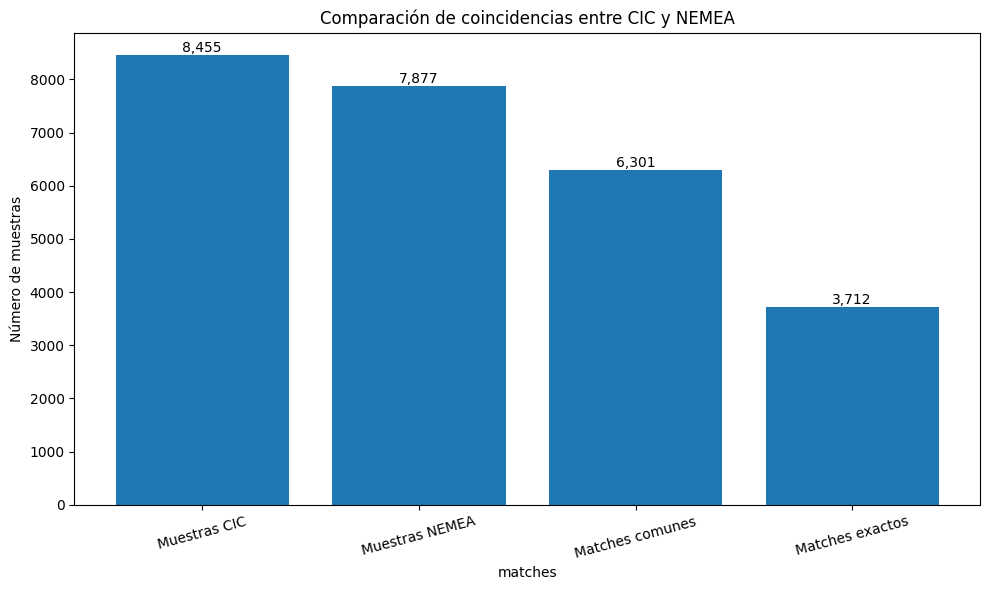

In [17]:
# ==========================================
# GRÁFICA 1 - RESUMEN DE COINCIDENCIAS
# ==========================================

import matplotlib.pyplot as plt

# Sustituye esto si ya tienes el número real
num_matches_exactos = len(matches_exactos_ms) if "matches_exactos" in globals() else 0

labels = ["Muestras CIC", "Muestras NEMEA", "Matches comunes", "Matches exactos"]
values = [len(muestras_cic), len(muestras_nemea), len(muestras_comunes), num_matches_exactos]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values)

plt.title("Comparación de coincidencias entre CIC y NEMEA")
plt.ylabel("Número de muestras")
plt.xlabel("matches")
plt.xticks(rotation=15)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()



In [18]:
# ============================================================
# CELDA 1 - CARGA DEL CSV MEZCLADO Y SEPARACIÓN TCP / UDP
# ============================================================
import pandas as pd
from pathlib import Path

ruta_tstat = Path("/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTstat/CSV/DictionaryBruteForce.csv")  # ← ajusta la ruta

df_tstat = pd.read_csv(ruta_tstat, low_memory=False)

print("=" * 55)
print("ESTRUCTURA DEL CSV MEZCLADO TCP+UDP")
print("=" * 55)
print(f"  Total filas:    {len(df_tstat)}")
print(f"  Total columnas: {len(df_tstat.columns)}")
print()
print(df_tstat["protocolo"].value_counts().to_string())
print()

# Separar por protocolo
df_tcp = df_tstat[df_tstat["protocolo"] == "TCP"].copy()
df_udp = df_tstat[df_tstat["protocolo"] == "UDP"].copy()

print(f"  TCP → {len(df_tcp)} filas  | usan: 'first', 'last', 'durat'")
print(f"  UDP → {len(df_udp)} filas  | usan: 'c_first_abs', 'c_durat', 's_durat'")
print()

# Las 6 columnas exclusivas de UDP (el resto son 0 en filas UDP)
cols_solo_udp = ["c_first_abs", "c_durat", "c_type", "s_first_abs", "s_durat", "s_type"]
print("6 columnas exclusivas de UDP (ceros en TCP):")
print(df_udp[cols_solo_udp].head(5).to_string())
print()
print("Esas mismas columnas en TCP (deben ser 0):")
print(df_tcp[cols_solo_udp].head(5).to_string())

ESTRUCTURA DEL CSV MEZCLADO TCP+UDP
  Total filas:    5401
  Total columnas: 138

protocolo
UDP    3543
TCP    1858

  TCP → 1858 filas  | usan: 'first', 'last', 'durat'
  UDP → 3543 filas  | usan: 'c_first_abs', 'c_durat', 's_durat'

6 columnas exclusivas de UDP (ceros en TCP):
       c_first_abs  c_durat  c_type  s_first_abs  s_durat  s_type
1858  1.665764e+12      0.0       0          0.0      0.0       0
1859  1.665764e+12      0.0       0          0.0      0.0       0
1860  1.665764e+12      0.0       0          0.0      0.0       0
1861  1.665764e+12      0.0       0          0.0      0.0       0
1862  1.665764e+12      0.0       0          0.0      0.0       0

Esas mismas columnas en TCP (deben ser 0):
   c_first_abs  c_durat  c_type  s_first_abs  s_durat  s_type
0          0.0      0.0       0          0.0      0.0       0
1          0.0      0.0       0          0.0      0.0       0
2          0.0      0.0       0          0.0      0.0       0
3          0.0      0.0       0 

In [19]:
# ── MUESTRA VISUAL ────────────────────────────────────────────────
print("\nEjemplo filas TCP (campos que usará el matching):")
print(df_tcp[["c_ip","c_port","s_ip","s_port","protocolo",
              "first","last","durat"]].head(5).to_string(index=False))

print("\nEjemplo filas UDP (campos que usará el matching):")
print(df_udp[["c_ip","c_port","s_ip","s_port","protocolo",
              "c_first_abs","c_durat","s_durat"]].head(5).to_string(index=False))


Ejemplo filas TCP (campos que usará el matching):
           c_ip  c_port           s_ip  s_port protocolo        first         last    durat
192.168.137.163   59239   47.254.83.84    1340       TCP 1.665764e+12 1.665764e+12  207.784
192.168.137.162   54248 52.217.104.252      80       TCP 1.665764e+12 1.665764e+12  236.159
192.168.137.188   52535  54.187.112.38     443       TCP 1.665764e+12 1.665764e+12  761.330
 192.168.137.78   57710  13.225.195.99     443       TCP 1.665764e+12 1.665764e+12 1382.894
 192.168.137.12   48964 44.230.212.240     443       TCP 1.665764e+12 1.665764e+12 3540.843

Ejemplo filas UDP (campos que usará el matching):
           c_ip  c_port            s_ip  s_port protocolo  c_first_abs  c_durat  s_durat
 192.168.137.52   10124   47.254.89.110   32100       UDP 1.665764e+12      0.0      0.0
 192.168.137.52   10124   47.90.209.117   32100       UDP 1.665764e+12      0.0      0.0
 192.168.137.52   10124 161.117.254.158   32100       UDP 1.665764e+12      0.0

In [20]:
# ============================================================
# CELDA 2 - TIMESTAMPS Y DURACIÓN: TCP y UDP usan campos distintos
# ============================================================

# ── TCP ─────────────────────────────────────────────────────────
# 'first' y 'last' → epoch en MILISEGUNDOS
# 'durat'          → duración en MILISEGUNDOS
df_tcp["first_dt"]         = pd.to_datetime(df_tcp["first"], unit="ms", errors="coerce")
df_tcp["first_utc2"]       = df_tcp["first_dt"] + pd.Timedelta(hours=2)
df_tcp["last_dt"]          = pd.to_datetime(df_tcp["last"],  unit="ms", errors="coerce")
df_tcp["last_utc2"]        = df_tcp["last_dt"]  + pd.Timedelta(hours=2)
df_tcp["flow_duration_us"] = df_tcp["durat"] * 1000   # ms → µs
df_tcp["proto_num"]        = 6

# ── UDP ─────────────────────────────────────────────────────────
# 'c_first_abs' → epoch en MILISEGUNDOS (misma unidad que 'first' de TCP)
# 'c_durat'     → duración en MILISEGUNDOS (misma unidad que 'durat' de TCP)
# OJO: 'c_durat' puede ser 0 en flujos unidireccionales (sin respuesta)
df_udp["first_dt"]         = pd.to_datetime(df_udp["c_first_abs"], unit="ms", errors="coerce")
df_udp["first_utc2"]       = df_udp["first_dt"] + pd.Timedelta(hours=2)
df_udp["flow_duration_us"] = df_udp["c_durat"].where(df_udp["c_durat"] > 0) * 1000
df_udp["proto_num"]        = 17

# ── Comprobación visual ─────────────────────────────────────────
print("=" * 65)
print("VERIFICACIÓN UTC+2 (deben coincidir con rango CIC ~18:18)")
print("=" * 65)
print(f"\n  CIC:        {df_cic_base['Timestamp'].min()}  →  {df_cic_base['Timestamp'].max()}")
print(f"  TCP sin+2h: {df_tcp['first_dt'].min()}  →  {df_tcp['first_dt'].max()}")
print(f"  TCP con+2h: {df_tcp['first_utc2'].min()}  →  {df_tcp['first_utc2'].max()}")
print(f"  UDP sin+2h: {df_udp['first_dt'].min()}  →  {df_udp['first_dt'].max()}")
print(f"  UDP con+2h: {df_udp['first_utc2'].min()}  →  {df_udp['first_utc2'].max()}")

print("\nEjemplo TCP — transformación timestamp y duración:")
print(df_tcp[["first","first_dt","first_utc2","durat","flow_duration_us"]].head(5).to_string(index=False))

print("\nEjemplo UDP — transformación timestamp y duración:")
print(df_udp[["c_first_abs","first_dt","first_utc2","c_durat","flow_duration_us"]].head(5).to_string(index=False))

# UDP sin duración
udp_sin_dur = df_udp[df_udp["flow_duration_us"].isna()]
udp_con_dur = df_udp[df_udp["flow_duration_us"].notna()]
print(f"\nUDP con duración (c_durat > 0):  {len(udp_con_dur)}  → matching exacto posible")
print(f"UDP sin duración (c_durat == 0): {len(udp_sin_dur)}  → solo matching por clave base")

VERIFICACIÓN UTC+2 (deben coincidir con rango CIC ~18:18)

  CIC:        2022-10-14 18:18:00  →  2022-10-17 17:02:00
  TCP sin+2h: 2022-10-14 16:18:03.317185059  →  2022-10-17 15:01:45.949112061
  TCP con+2h: 2022-10-14 18:18:03.317185059  →  2022-10-17 17:01:45.949112061
  UDP sin+2h: 2022-10-14 16:18:00.452805908  →  2022-10-17 15:02:00.354792725
  UDP con+2h: 2022-10-14 18:18:00.452805908  →  2022-10-17 17:02:00.354792725

Ejemplo TCP — transformación timestamp y duración:
       first                      first_dt                    first_utc2    durat  flow_duration_us
1.665764e+12 2022-10-14 16:18:03.317185059 2022-10-14 18:18:03.317185059  207.784          207784.0
1.665764e+12 2022-10-14 16:18:04.112904053 2022-10-14 18:18:04.112904053  236.159          236159.0
1.665764e+12 2022-10-14 16:18:16.047460693 2022-10-14 18:18:16.047460693  761.330          761330.0
1.665764e+12 2022-10-14 16:18:16.749930908 2022-10-14 18:18:16.749930908 1382.894         1382894.0
1.665764e+12 2022-1

In [21]:
# ── MUESTRA VISUAL ────────────────────────────────────────────────
print("\nTCP — transformación completa fila a fila:")
print(df_tcp[["c_ip","c_port","s_ip","s_port",
              "first","first_utc2",
              "durat","flow_duration_us"]].head(8).to_string(index=False))

print("\nUDP — transformación completa fila a fila:")
print(df_udp[["c_ip","c_port","s_ip","s_port",
              "c_first_abs","first_utc2",
              "c_durat","flow_duration_us"]].head(8).to_string(index=False))

print("\nUDP sin duración (flow_duration_us = NaN) — flujos unidireccionales:")
print(df_udp[df_udp["flow_duration_us"].isna()][
    ["c_ip","c_port","s_ip","s_port","first_utc2","c_durat","flow_duration_us"]
].head(5).to_string(index=False))


TCP — transformación completa fila a fila:
           c_ip  c_port           s_ip  s_port        first                    first_utc2     durat  flow_duration_us
192.168.137.163   59239   47.254.83.84    1340 1.665764e+12 2022-10-14 18:18:03.317185059   207.784          207784.0
192.168.137.162   54248 52.217.104.252      80 1.665764e+12 2022-10-14 18:18:04.112904053   236.159          236159.0
192.168.137.188   52535  54.187.112.38     443 1.665764e+12 2022-10-14 18:18:16.047460693   761.330          761330.0
 192.168.137.78   57710  13.225.195.99     443 1.665764e+12 2022-10-14 18:18:16.749930908  1382.894         1382894.0
 192.168.137.12   48964 44.230.212.240     443 1.665764e+12 2022-10-14 18:18:19.357488037  3540.843         3540843.0
192.168.137.107   49548  13.225.195.54     443 1.665764e+12 2022-10-14 18:18:43.846971924   345.819          345819.0
192.168.137.163   59243   47.254.83.84    1340 1.665764e+12 2022-10-14 18:18:53.109774902   198.780          198780.0
 192.168.137

In [22]:
# ============================================================
# CELDA 3 - CONSTRUIR BASE UNIFICADA PARA MATCHING
# ============================================================

cols_base = ["c_ip", "c_port", "s_ip", "s_port",
             "proto_num", "first_utc2", "flow_duration_us", "etiqueta"]

df_tstat_base = pd.concat([
    df_tcp[cols_base],
    df_udp[cols_base]
], ignore_index=True)

df_tstat_base["time_sec"] = df_tstat_base["first_utc2"].dt.floor("s")

print("=" * 55)
print("BASE UNIFICADA PARA MATCHING")
print("=" * 55)
print(f"  TCP:   {len(df_tcp)}")
print(f"  UDP:   {len(df_udp)}")
print(f"  TOTAL: {len(df_tstat_base)}")
print()
print(df_tstat_base[["c_ip","c_port","s_ip","s_port",
                      "proto_num","first_utc2","flow_duration_us"]].head(8).to_string(index=False))

BASE UNIFICADA PARA MATCHING
  TCP:   1858
  UDP:   3543
  TOTAL: 5401

           c_ip  c_port           s_ip  s_port  proto_num                    first_utc2  flow_duration_us
192.168.137.163   59239   47.254.83.84    1340          6 2022-10-14 18:18:03.317185059          207784.0
192.168.137.162   54248 52.217.104.252      80          6 2022-10-14 18:18:04.112904053          236159.0
192.168.137.188   52535  54.187.112.38     443          6 2022-10-14 18:18:16.047460693          761330.0
 192.168.137.78   57710  13.225.195.99     443          6 2022-10-14 18:18:16.749930908         1382894.0
 192.168.137.12   48964 44.230.212.240     443          6 2022-10-14 18:18:19.357488037         3540843.0
192.168.137.107   49548  13.225.195.54     443          6 2022-10-14 18:18:43.846971924          345819.0
192.168.137.163   59243   47.254.83.84    1340          6 2022-10-14 18:18:53.109774902          198780.0
 192.168.137.50   54807 192.168.137.89   55443          6 2022-10-14 18:18:35.07

In [23]:
# ── MUESTRA VISUAL ────────────────────────────────────────────────
print("\nBase unificada — primeras filas (TCP primero, luego UDP):")
print(df_tstat_base[["c_ip","c_port","s_ip","s_port","proto_num",
                      "first_utc2","time_sec",
                      "flow_duration_us"]].head(12).to_string(index=False))

print(f"\nProto 6 (TCP) en base: {(df_tstat_base['proto_num']==6).sum()}")
print(f"Proto 17 (UDP) en base: {(df_tstat_base['proto_num']==17).sum()}")
print(f"  → UDP con duración:   {df_tstat_base[(df_tstat_base['proto_num']==17) & df_tstat_base['flow_duration_us'].notna()].shape[0]}")
print(f"  → UDP sin duración:   {df_tstat_base[(df_tstat_base['proto_num']==17) & df_tstat_base['flow_duration_us'].isna()].shape[0]}")


Base unificada — primeras filas (TCP primero, luego UDP):
           c_ip  c_port           s_ip  s_port  proto_num                    first_utc2            time_sec  flow_duration_us
192.168.137.163   59239   47.254.83.84    1340          6 2022-10-14 18:18:03.317185059 2022-10-14 18:18:03          207784.0
192.168.137.162   54248 52.217.104.252      80          6 2022-10-14 18:18:04.112904053 2022-10-14 18:18:04          236159.0
192.168.137.188   52535  54.187.112.38     443          6 2022-10-14 18:18:16.047460693 2022-10-14 18:18:16          761330.0
 192.168.137.78   57710  13.225.195.99     443          6 2022-10-14 18:18:16.749930908 2022-10-14 18:18:16         1382894.0
 192.168.137.12   48964 44.230.212.240     443          6 2022-10-14 18:18:19.357488037 2022-10-14 18:18:19         3540843.0
192.168.137.107   49548  13.225.195.54     443          6 2022-10-14 18:18:43.846971924 2022-10-14 18:18:43          345819.0
192.168.137.163   59243   47.254.83.84    1340          6 2

In [24]:
# ============================================================
# CELDA 4 - CLAVE BASE (5-tupla + segundo)
#           Directa e Invertida
# ============================================================

# CIC
df_cic_base["time_sec"] = df_cic_base["Timestamp"].dt.floor("s")

df_cic_base["key_base"] = list(zip(
    df_cic_base["Src IP"].astype(str),
    df_cic_base["Src Port"].astype(str),
    df_cic_base["Dst IP"].astype(str),
    df_cic_base["Dst Port"].astype(str),
    df_cic_base["Protocol"].astype(str),
    df_cic_base["time_sec"].astype(str)
))

# TSTAT directa (c_ip = Src)
df_tstat_base["key_base_dir"] = list(zip(
    df_tstat_base["c_ip"].astype(str),
    df_tstat_base["c_port"].astype(str),
    df_tstat_base["s_ip"].astype(str),
    df_tstat_base["s_port"].astype(str),
    df_tstat_base["proto_num"].astype(str),
    df_tstat_base["time_sec"].astype(str)
))

# TSTAT invertida (s_ip = Src)
df_tstat_base["key_base_inv"] = list(zip(
    df_tstat_base["s_ip"].astype(str),
    df_tstat_base["s_port"].astype(str),
    df_tstat_base["c_ip"].astype(str),
    df_tstat_base["c_port"].astype(str),
    df_tstat_base["proto_num"].astype(str),
    df_tstat_base["time_sec"].astype(str)
))

claves_cic       = set(df_cic_base["key_base"])
claves_tstat_dir = set(df_tstat_base["key_base_dir"])
claves_tstat_inv = set(df_tstat_base["key_base_inv"])

comunes_dir = claves_cic & claves_tstat_dir
comunes_inv = claves_cic & claves_tstat_inv
comunes_tot = comunes_dir | comunes_inv

print("=" * 55)
print("CLAVE BASE (5-tupla + segundo)")
print("=" * 55)
print(f"  Claves CIC:               {len(claves_cic)}")
print(f"  Claves TSTAT (directa):   {len(claves_tstat_dir)}")
print(f"  Comunes directa:          {len(comunes_dir)}")
print(f"  Comunes invertida:        {len(comunes_inv)}")
print(f"  TOTAL comunes:            {len(comunes_tot)}")
print(f"  % sobre CIC:   {round(len(comunes_tot)/len(claves_cic)*100,2)}%")
print(f"  % sobre TSTAT: {round(len(comunes_tot)/len(claves_tstat_dir)*100,2)}%")

CLAVE BASE (5-tupla + segundo)
  Claves CIC:               8455
  Claves TSTAT (directa):   5401
  Comunes directa:          4695
  Comunes invertida:        23
  TOTAL comunes:            4718
  % sobre CIC:   55.8%
  % sobre TSTAT: 87.35%


In [25]:
# ── MUESTRA VISUAL ────────────────────────────────────────────────
print("\nEjemplo claves base CIC (lo que se busca en TSTAT):")
for k in list(claves_cic)[:5]:
    print(f"  {k}")

print("\nEjemplo claves base TSTAT directa:")
for k in list(claves_tstat_dir)[:5]:
    print(f"  {k}")

print("\nEjemplo claves base TSTAT invertida:")
for k in list(claves_tstat_inv)[:5]:
    print(f"  {k}")

print(f"\nEjemplo de {len(comunes_dir)} claves que coinciden en DIRECTA:")
for k in list(comunes_dir)[:5]:
    print(f"  {k}")

print(f"\nEjemplo de {len(comunes_inv)} claves que coinciden en INVERTIDA:")
for k in list(comunes_inv)[:5]:
    print(f"  {k}")

# Ver las filas reales de TSTAT que matchean en directa
df_muestra_dir = df_tstat_base[df_tstat_base["key_base_dir"].isin(comunes_dir)].head(5)
df_muestra_inv = df_tstat_base[df_tstat_base["key_base_inv"].isin(comunes_inv)].head(5)
df_muestra_cic_dir = df_cic_base[df_cic_base["key_base"].isin(comunes_dir)].head(5)
df_muestra_cic_inv = df_cic_base[df_cic_base["key_base"].isin(comunes_inv)].head(5)

print(f"\n─── {len(comunes_dir)} matches directos: TSTAT c_ip = CIC Src IP ───")
print("TSTAT:")
print(df_muestra_dir[["c_ip","c_port","s_ip","s_port",
                       "proto_num","time_sec"]].to_string(index=False))
print("CIC:")
print(df_muestra_cic_dir[["Src IP","Src Port","Dst IP","Dst Port",
                           "Protocol","time_sec"]].to_string(index=False))

print(f"\n─── {len(comunes_inv)} matches invertidos: TSTAT s_ip = CIC Src IP ───")
print("TSTAT:")
print(df_muestra_inv[["c_ip","c_port","s_ip","s_port",
                       "proto_num","time_sec"]].to_string(index=False))
print("CIC:")
print(df_muestra_cic_inv[["Src IP","Src Port","Dst IP","Dst Port",
                           "Protocol","time_sec"]].to_string(index=False))


Ejemplo claves base CIC (lo que se busca en TSTAT):
  ('192.168.137.242', '0', '192.168.137.1', '0', '0', '2022-10-17 15:25:19')
  ('192.168.137.173', '18511', '47.112.162.49', '32100', '17', '2022-10-17 15:29:29')
  ('192.168.137.1', '53', '192.168.137.173', '42955', '17', '2022-10-17 15:38:32')
  ('192.168.137.147', '54194', '54.202.68.76', '9999', '6', '2022-10-17 15:41:25')
  ('192.168.137.242', '60914', '8.8.4.4', '53', '17', '2022-10-17 15:36:22')

Ejemplo claves base TSTAT directa:
  ('192.168.137.173', '18511', '47.112.162.49', '32100', '17', '2022-10-17 15:29:29')
  ('192.168.137.1', '53', '192.168.137.173', '42955', '17', '2022-10-17 15:38:32')
  ('192.168.137.147', '54194', '54.202.68.76', '9999', '6', '2022-10-17 15:41:25')
  ('192.168.137.242', '60914', '8.8.4.4', '53', '17', '2022-10-17 15:36:22')
  ('192.168.137.197', '44831', '8.208.8.243', '53', '17', '2022-10-17 15:50:56')

Ejemplo claves base TSTAT invertida:
  ('192.168.137.140', '554', '192.168.137.65', '59612', '

In [26]:
# ============================================================
# CELDA 5 - MATCH EXACTO: PRUEBA 1 (µs) y PRUEBA 2 (ms)
#           Solo para filas con duración disponible
# ============================================================

# Solo filas con duración
df_tstat_dur = df_tstat_base[df_tstat_base["flow_duration_us"].notna()].copy()
df_tstat_dur["durat_ms"] = (df_tstat_dur["flow_duration_us"] / 1000).round().astype("Int64")

# CIC duración
df_cic_base["Flow Duration_ms"] = (
    pd.to_numeric(df_cic_base["Flow Duration"], errors="coerce") / 1000
).round().astype("Int64")

# ── PRUEBA 1: duración en µs ─────────────────────────────────────
# CIC: Flow Duration (µs entero) | TSTAT: durat*1000 redondeado a Int64
df_cic_base["key_p1"] = list(zip(
    df_cic_base["Src IP"].astype(str), df_cic_base["Src Port"].astype(str),
    df_cic_base["Dst IP"].astype(str), df_cic_base["Dst Port"].astype(str),
    df_cic_base["Protocol"].astype(str), df_cic_base["time_sec"].astype(str),
    df_cic_base["Flow Duration"].astype("Int64").astype(str)
))
df_tstat_dur["key_p1_dir"] = list(zip(
    df_tstat_dur["c_ip"].astype(str), df_tstat_dur["c_port"].astype(str),
    df_tstat_dur["s_ip"].astype(str), df_tstat_dur["s_port"].astype(str),
    df_tstat_dur["proto_num"].astype(str), df_tstat_dur["time_sec"].astype(str),
    df_tstat_dur["flow_duration_us"].round().astype("Int64").astype(str)
))
df_tstat_dur["key_p1_inv"] = list(zip(
    df_tstat_dur["s_ip"].astype(str), df_tstat_dur["s_port"].astype(str),
    df_tstat_dur["c_ip"].astype(str), df_tstat_dur["c_port"].astype(str),
    df_tstat_dur["proto_num"].astype(str), df_tstat_dur["time_sec"].astype(str),
    df_tstat_dur["flow_duration_us"].round().astype("Int64").astype(str)
))

p1_dir = set(df_cic_base["key_p1"]) & set(df_tstat_dur["key_p1_dir"])
p1_inv = set(df_cic_base["key_p1"]) & set(df_tstat_dur["key_p1_inv"])
p1     = p1_dir | p1_inv

# ── PRUEBA 2: duración en ms ─────────────────────────────────────
# CIC: Flow Duration / 1000 redondeado | TSTAT: durat redondeado
df_cic_base["key_p2"] = list(zip(
    df_cic_base["Src IP"].astype(str), df_cic_base["Src Port"].astype(str),
    df_cic_base["Dst IP"].astype(str), df_cic_base["Dst Port"].astype(str),
    df_cic_base["Protocol"].astype(str), df_cic_base["time_sec"].astype(str),
    df_cic_base["Flow Duration_ms"].astype(str)
))
df_tstat_dur["key_p2_dir"] = list(zip(
    df_tstat_dur["c_ip"].astype(str), df_tstat_dur["c_port"].astype(str),
    df_tstat_dur["s_ip"].astype(str), df_tstat_dur["s_port"].astype(str),
    df_tstat_dur["proto_num"].astype(str), df_tstat_dur["time_sec"].astype(str),
    df_tstat_dur["durat_ms"].astype(str)
))
df_tstat_dur["key_p2_inv"] = list(zip(
    df_tstat_dur["s_ip"].astype(str), df_tstat_dur["s_port"].astype(str),
    df_tstat_dur["c_ip"].astype(str), df_tstat_dur["c_port"].astype(str),
    df_tstat_dur["proto_num"].astype(str), df_tstat_dur["time_sec"].astype(str),
    df_tstat_dur["durat_ms"].astype(str)
))

p2_dir = set(df_cic_base["key_p2"]) & set(df_tstat_dur["key_p2_dir"])
p2_inv = set(df_cic_base["key_p2"]) & set(df_tstat_dur["key_p2_inv"])
p2     = p2_dir | p2_inv

print("=" * 55)
print("MATCH EXACTO CON DURACIÓN")
print("=" * 55)
print(f"  TSTAT filas con duración disponible: {len(df_tstat_dur)}")
print(f"    TCP (durat>0):     {len(df_tstat_dur[df_tstat_dur['proto_num']==6])}")
print(f"    UDP (c_durat>0):   {len(df_tstat_dur[df_tstat_dur['proto_num']==17])}")
print()
print(f"  PRUEBA 1 (µs exacto):")
print(f"    Directos:   {len(p1_dir)}")
print(f"    Invertidos: {len(p1_inv)}")
print(f"    TOTAL P1:   {len(p1)}")
print()
print(f"  PRUEBA 2 (ms redondeado):")
print(f"    Directos:   {len(p2_dir)}")
print(f"    Invertidos: {len(p2_inv)}")
print(f"    TOTAL P2:   {len(p2)}")
print()

# La mejor
mejor_p = p2 if len(p2) >= len(p1) else p1
key_dir = "key_p2_dir" if len(p2) >= len(p1) else "key_p1_dir"
key_inv = "key_p2_inv" if len(p2) >= len(p1) else "key_p1_inv"
key_cic = "key_p2"     if len(p2) >= len(p1) else "key_p1"
nombre_p = "P2 (ms)" if len(p2) >= len(p1) else "P1 (µs)"

print(f"  → Mejor prueba: {nombre_p} con {len(mejor_p)} matches")
print(f"  % sobre CIC:    {round(len(mejor_p)/len(df_cic_base)*100,2)}%")
print(f"  % sobre TSTAT:  {round(len(mejor_p)/len(df_tstat_base)*100,2)}%")

MATCH EXACTO CON DURACIÓN
  TSTAT filas con duración disponible: 2747
    TCP (durat>0):     1858
    UDP (c_durat>0):   889

  PRUEBA 1 (µs exacto):
    Directos:   1181
    Invertidos: 0
    TOTAL P1:   1181

  PRUEBA 2 (ms redondeado):
    Directos:   1211
    Invertidos: 0
    TOTAL P2:   1211

  → Mejor prueba: P2 (ms) con 1211 matches
  % sobre CIC:    14.16%
  % sobre TSTAT:  22.42%


In [27]:
# ── MUESTRA VISUAL ────────────────────────────────────────────────

# Ejemplo claves exactas P2 que matchean
print(f"Ejemplo de claves exactas P2 que coinciden (directa):")
for k in list(p2_dir)[:4]:
    print(f"  {k}")

print(f"\nEjemplo de claves exactas P2 que coinciden (invertida):")
for k in list(p2_inv)[:4]:
    print(f"  {k}")

# Matches que P2 encuentra pero P1 NO
solo_en_p2 = p2 - p1
print(f"\nMatches que P2 encuentra pero P1 NO: {len(solo_en_p2)}")
if len(solo_en_p2) > 0:
    print("→ Estos son flujos donde el redondeo a ms absorbe diferencias de coma flotante")
    print("Ejemplo de esas claves (p2 pero no p1):")
    for k in list(solo_en_p2)[:3]:
        print(f"  {k}")

# Ver las filas reales detrás de los matches exactos P2
df_exactos_tstat_muestra = df_tstat_dur[
    df_tstat_dur[key_dir].isin(list(mejor_p)[:5]) |
    df_tstat_dur[key_inv].isin(list(mejor_p)[:5])
].head(5)
df_exactos_cic_muestra = df_cic_base[
    df_cic_base[key_cic].isin(list(mejor_p)[:5])
].head(5)

print(f"\n─── Filas reales detrás de los {len(mejor_p)} matches exactos ({nombre_p}) ───")
print("TSTAT:")
print(df_exactos_tstat_muestra[[
    "c_ip","c_port","s_ip","s_port","proto_num",
    "time_sec","flow_duration_us","durat_ms"
]].to_string(index=False))
print("CIC:")
print(df_exactos_cic_muestra[[
    "Src IP","Src Port","Dst IP","Dst Port","Protocol",
    "time_sec","Flow Duration","Flow Duration_ms"
]].to_string(index=False))

print(f"""
Lectura de los números:
  Clave base comunes:  {len(comunes_tot):>6}  (5-tupla + segundo, sin duración)
  Matches exactos P1:  {len(p1):>6}  (añadiendo duración en µs)
  Matches exactos P2:  {len(p2):>6}  (añadiendo duración en ms, más tolerante)
  Solo en P2 no P1:    {len(solo_en_p2):>6}  (diferencias de coma flotante absorbidas al redondear)
""")

Ejemplo de claves exactas P2 que coinciden (directa):
  ('192.168.137.147', '54254', '54.202.68.76', '9999', '6', '2022-10-17 15:43:27', '123')
  ('192.168.137.147', '54074', '54.202.68.76', '9999', '6', '2022-10-17 15:37:23', '112')
  ('192.168.137.150', '52909', '54.148.192.245', '443', '6', '2022-10-17 15:28:46', '8754')
  ('192.168.137.147', '54182', '54.202.68.76', '9999', '6', '2022-10-17 15:41:01', '117')

Ejemplo de claves exactas P2 que coinciden (invertida):

Matches que P2 encuentra pero P1 NO: 1211
→ Estos son flujos donde el redondeo a ms absorbe diferencias de coma flotante
Ejemplo de esas claves (p2 pero no p1):
  ('192.168.137.147', '54254', '54.202.68.76', '9999', '6', '2022-10-17 15:43:27', '123')
  ('192.168.137.147', '54074', '54.202.68.76', '9999', '6', '2022-10-17 15:37:23', '112')
  ('192.168.137.150', '52909', '54.148.192.245', '443', '6', '2022-10-17 15:28:46', '8754')

─── Filas reales detrás de los 1211 matches exactos (P2 (ms)) ───
TSTAT:
           c_ip  c_

Shape CIC exactos:   (1211, 17)
Shape TSTAT exactos: (1211, 16)


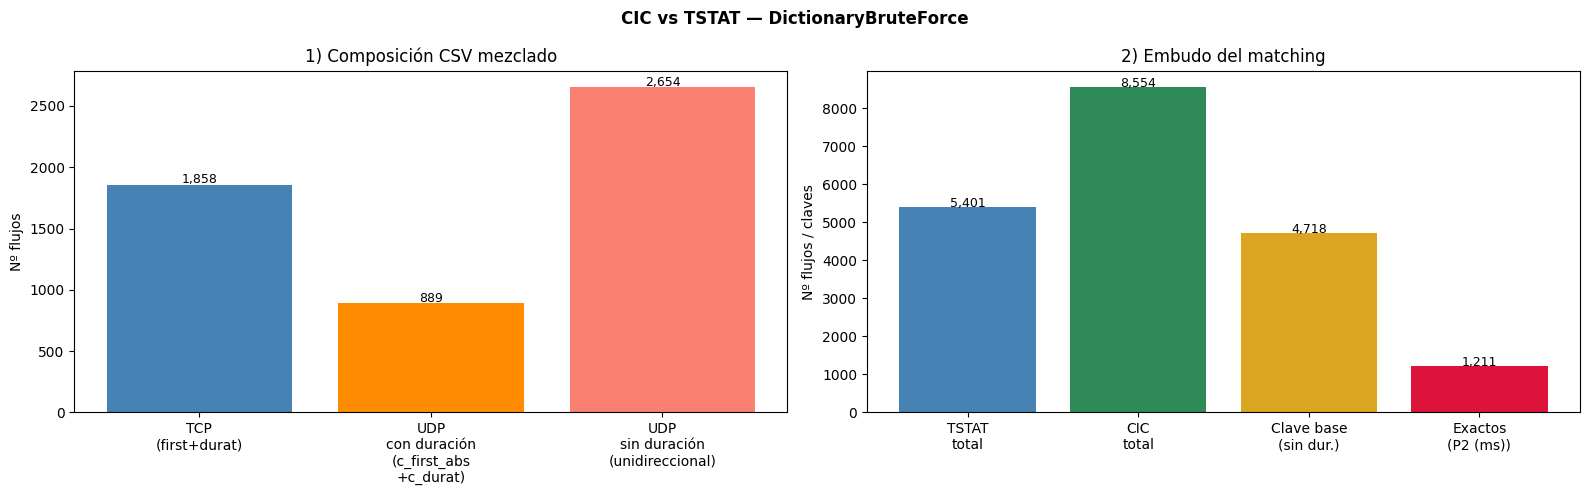

In [28]:
# ============================================================
# CELDA 6 - FILTRAR DATASETS FINALES Y GRÁFICA
# ============================================================
import matplotlib.pyplot as plt

df_cic_exactos   = df_cic_base[df_cic_base[key_cic].isin(mejor_p)].copy()
df_tstat_exactos = df_tstat_dur[
    df_tstat_dur[key_dir].isin(mejor_p) |
    df_tstat_dur[key_inv].isin(mejor_p)
].copy()

print(f"Shape CIC exactos:   {df_cic_exactos.shape}")
print(f"Shape TSTAT exactos: {df_tstat_exactos.shape}")

# ── Gráfica ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("CIC vs TSTAT — DictionaryBruteForce", fontsize=12, fontweight="bold")

# Composición CSV
ax1 = axes[0]
vals = [len(df_tcp), len(df_udp[df_udp["c_durat"]>0]), len(df_udp[df_udp["c_durat"]==0])]
labs = ["TCP\n(first+durat)", "UDP\ncon duración\n(c_first_abs\n+c_durat)", "UDP\nsin duración\n(unidireccional)"]
bars = ax1.bar(labs, vals, color=["steelblue","darkorange","salmon"])
ax1.set_title("1) Composición CSV mezclado")
ax1.set_ylabel("Nº flujos")
for b, v in zip(bars, vals):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+10, f"{v:,}", ha="center", fontsize=9)

# Embudo matching
ax2 = axes[1]
vals2 = [len(df_tstat_base), len(df_cic_base), len(comunes_tot), len(mejor_p)]
labs2 = ["TSTAT\ntotal", "CIC\ntotal", "Clave base\n(sin dur.)", f"Exactos\n({nombre_p})"]
bars2 = ax2.bar(labs2, vals2, color=["steelblue","seagreen","goldenrod","crimson"])
ax2.set_title("2) Embudo del matching")
ax2.set_ylabel("Nº flujos / claves")
for b, v in zip(bars2, vals2):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+5, f"{v:,}", ha="center", fontsize=9)



plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# CELDA T1 - CARGA DEL CSV DE TSHARK
# ============================================================

ruta_tshark = Path("/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTshark_2/Csv/DictionaryBruteForce.csv")

df_tshark = pd.read_csv(ruta_tshark, low_memory=False)

print("[TSHARK] Shape:", df_tshark.shape)
print()
print("Distribución por protocolo:")
print(df_tshark["proto"].value_counts())
print()
print("Columnas de matching disponibles:")
print(df_tshark[["src_ip","dst_ip","src_port","dst_port",
                  "proto_num","start_epoch","flow_duration_s",
                  "proto","category"]].head(6).to_string(index=False))

[TSHARK] Shape: (5736, 64)

Distribución por protocolo:
proto
UDP    3104
TCP    2632
Name: count, dtype: int64

Columnas de matching disponibles:
         src_ip         dst_ip  src_port  dst_port  proto_num  start_epoch  flow_duration_s proto             category
192.168.137.208  35.186.43.132     53345       443          6 1.665764e+09       900.550069   TCP DictionaryBruteForce
192.168.137.174 185.209.178.72      4608       443          6 1.665764e+09       899.693038   TCP DictionaryBruteForce
 192.168.137.51 54.218.246.107     45050       443          6 1.665764e+09       897.330553   TCP DictionaryBruteForce
 192.168.137.78   52.15.60.193     42972       443          6 1.665764e+09       888.554747   TCP DictionaryBruteForce
192.168.137.188    54.188.99.4     40402      8886          6 1.665764e+09       842.777609   TCP DictionaryBruteForce
192.168.137.163 120.76.210.199     41643        80          6 1.665764e+09         7.007094   TCP DictionaryBruteForce


In [30]:
# ============================================================
# CELDA T2 - TIMESTAMP + UTC+2 + DURACIÓN
# ============================================================

# start_epoch está en segundos UNIX UTC
# → igual que Nemea y Tstat, aplicamos +2h para alinearlo con CIC
df_tshark["start_dt"]   = pd.to_datetime(df_tshark["start_epoch"], unit="s", errors="coerce")
df_tshark["start_utc2"] = df_tshark["start_dt"] + pd.Timedelta(hours=2)
df_tshark["time_sec"]   = df_tshark["start_utc2"].dt.floor("s")

# flow_duration_s está en segundos → convertir a µs y a ms para las dos pruebas
df_tshark["flow_duration_us"] = (df_tshark["flow_duration_s"] * 1_000_000).round().astype("Int64")
df_tshark["flow_duration_ms"] = (df_tshark["flow_duration_s"] * 1_000).round().astype("Int64")

print("=" * 60)
print("VERIFICACIÓN UTC+2")
print("=" * 60)
print(f"  CIC:            {df_cic_base['Timestamp'].min()}  →  {df_cic_base['Timestamp'].max()}")
print(f"  TSHARK sin +2h: {df_tshark['start_dt'].min()}  →  {df_tshark['start_dt'].max()}")
print(f"  TSHARK con +2h: {df_tshark['start_utc2'].min()}  →  {df_tshark['start_utc2'].max()}")
print()
print("Ejemplo transformación fila a fila:")
print(df_tshark[["src_ip","src_port","dst_ip","dst_port",
                  "start_epoch","start_dt","start_utc2",
                  "flow_duration_s","flow_duration_us","flow_duration_ms"]].head(6).to_string(index=False))

VERIFICACIÓN UTC+2
  CIC:            2022-10-14 18:18:00  →  2022-10-17 17:02:00
  TSHARK sin +2h: 2022-10-14 16:18:00.400262117  →  2022-10-17 15:02:00.354793072
  TSHARK con +2h: 2022-10-14 18:18:00.400262117  →  2022-10-17 17:02:00.354793072

Ejemplo transformación fila a fila:
         src_ip  src_port         dst_ip  dst_port  start_epoch                      start_dt                    start_utc2  flow_duration_s  flow_duration_us  flow_duration_ms
192.168.137.208     53345  35.186.43.132       443 1.665764e+09 2022-10-14 16:18:00.400262117 2022-10-14 18:18:00.400262117       900.550069         900550069            900550
192.168.137.174      4608 185.209.178.72       443 1.665764e+09 2022-10-14 16:18:00.612818003 2022-10-14 18:18:00.612818003       899.693038         899693038            899693
 192.168.137.51     45050 54.218.246.107       443 1.665764e+09 2022-10-14 16:18:00.892472029 2022-10-14 18:18:00.892472029       897.330553         897330553            897331
 192.168.1

In [31]:
# ============================================================
# CELDA T3 - TSHARK BASE LIMPIO
# ============================================================

df_tshark_base = df_tshark[[
    "src_ip","dst_ip","src_port","dst_port",
    "proto_num","start_utc2","time_sec",
    "flow_duration_us","flow_duration_ms","proto","category"
]].copy()

df_tshark_base = df_tshark_base.sort_values(
    by=["start_utc2"]
).reset_index(drop=True)

print("TSHARK base ordenado:")
print(df_tshark_base[["src_ip","dst_ip","src_port","dst_port",
                       "proto_num","start_utc2","flow_duration_us"]].head(8).to_string(index=False))
print()
print(f"Proto 6  (TCP): {(df_tshark_base['proto_num']==6).sum()}")
print(f"Proto 17 (UDP): {(df_tshark_base['proto_num']==17).sum()}")

TSHARK base ordenado:
         src_ip          dst_ip  src_port  dst_port  proto_num                    start_utc2  flow_duration_us
192.168.137.208   35.186.43.132     53345       443          6 2022-10-14 18:18:00.400262117         900550069
 192.168.137.52   47.254.89.110     10124     32100         17 2022-10-14 18:18:00.452805996         876448413
 192.168.137.52   47.90.209.117     10124     32100         17 2022-10-14 18:18:00.452810049         876386940
 192.168.137.52 161.117.254.158     10124     32100         17 2022-10-14 18:18:00.452811003         876582578
192.168.137.174  185.209.178.72      4608       443          6 2022-10-14 18:18:00.612818003         899693038
 192.168.137.73 255.255.255.255     49154      6667         17 2022-10-14 18:18:00.669980049         895003863
192.168.137.152 255.255.255.255     49153      6667         17 2022-10-14 18:18:00.817343950         896804644
192.168.137.201 239.255.255.251     10101     10101         17 2022-10-14 18:18:00.8173599

In [32]:
# ============================================================
# CELDA T4 - CLAVE BASE (5-tupla + segundo)
#            Directa e Invertida
# ============================================================

# CIC (ya la tienes de las celdas de Nemea/Tstat, pero recalculamos por si acaso)
df_cic_base["time_sec"] = df_cic_base["Timestamp"].dt.floor("s")

df_cic_base["flow_key_base_tshark"] = list(zip(
    df_cic_base["Src IP"].astype(str),
    df_cic_base["Src Port"].astype(str),
    df_cic_base["Dst IP"].astype(str),
    df_cic_base["Dst Port"].astype(str),
    df_cic_base["Protocol"].astype(str),
    df_cic_base["time_sec"].astype(str)
))

# TSHARK directa (src_ip = Src CIC)
df_tshark_base["key_base_dir"] = list(zip(
    df_tshark_base["src_ip"].astype(str),
    df_tshark_base["src_port"].astype(str),
    df_tshark_base["dst_ip"].astype(str),
    df_tshark_base["dst_port"].astype(str),
    df_tshark_base["proto_num"].astype(str),
    df_tshark_base["time_sec"].astype(str)
))

# TSHARK invertida (dst_ip = Src CIC)
df_tshark_base["key_base_inv"] = list(zip(
    df_tshark_base["dst_ip"].astype(str),
    df_tshark_base["dst_port"].astype(str),
    df_tshark_base["src_ip"].astype(str),
    df_tshark_base["src_port"].astype(str),
    df_tshark_base["proto_num"].astype(str),
    df_tshark_base["time_sec"].astype(str)
))

claves_cic        = set(df_cic_base["flow_key_base_tshark"])
claves_tshark_dir = set(df_tshark_base["key_base_dir"])
claves_tshark_inv = set(df_tshark_base["key_base_inv"])

comunes_dir = claves_cic & claves_tshark_dir
comunes_inv = claves_cic & claves_tshark_inv
comunes_tot = comunes_dir | comunes_inv

print("=" * 55)
print("CLAVE BASE (5-tupla + segundo)")
print("=" * 55)
print(f"  Claves CIC:              {len(claves_cic)}")
print(f"  Claves TSHARK directa:   {len(claves_tshark_dir)}")
print(f"  Comunes directa:         {len(comunes_dir)}")
print(f"  Comunes invertida:       {len(comunes_inv)}")
print(f"  TOTAL comunes:           {len(comunes_tot)}")
print(f"  % sobre CIC:   {round(len(comunes_tot)/len(claves_cic)*100,2)}%")
print(f"  % sobre TSHARK: {round(len(comunes_tot)/len(claves_tshark_dir)*100,2)}%")
print()
print(f"Ejemplo claves comunes directa:")
for k in list(comunes_dir)[:4]:
    print(f"  {k}")
print(f"\nEjemplo claves comunes invertida:")
for k in list(comunes_inv)[:4]:
    print(f"  {k}")

CLAVE BASE (5-tupla + segundo)
  Claves CIC:              8455
  Claves TSHARK directa:   5736
  Comunes directa:         5253
  Comunes invertida:       37
  TOTAL comunes:           5290
  % sobre CIC:   62.57%
  % sobre TSHARK: 92.22%

Ejemplo claves comunes directa:
  ('192.168.137.173', '18511', '47.112.162.49', '32100', '17', '2022-10-17 15:29:29')
  ('192.168.137.1', '53', '192.168.137.173', '42955', '17', '2022-10-17 15:38:32')
  ('192.168.137.147', '54194', '54.202.68.76', '9999', '6', '2022-10-17 15:41:25')
  ('192.168.137.242', '60914', '8.8.4.4', '53', '17', '2022-10-17 15:36:22')

Ejemplo claves comunes invertida:
  ('34.195.163.206', '443', '192.168.137.187', '57491', '6', '2022-10-17 15:27:04')
  ('3.225.140.71', '443', '192.168.137.162', '49842', '6', '2022-10-17 15:29:58')
  ('52.17.3.182', '443', '192.168.137.76', '59563', '6', '2022-10-17 15:39:23')
  ('52.26.167.43', '8443', '192.168.137.242', '52395', '6', '2022-10-17 15:27:17')


In [33]:
# ============================================================
# CELDA T4 - CLAVE BASE (5-tupla + segundo)
#            Directa e Invertida
# ============================================================

# CIC (ya la tienes de las celdas de Nemea/Tstat, pero recalculamos por si acaso)
df_cic_base["time_sec"] = df_cic_base["Timestamp"].dt.floor("s")

df_cic_base["flow_key_base_tshark"] = list(zip(
    df_cic_base["Src IP"].astype(str),
    df_cic_base["Src Port"].astype(str),
    df_cic_base["Dst IP"].astype(str),
    df_cic_base["Dst Port"].astype(str),
    df_cic_base["Protocol"].astype(str),
    df_cic_base["time_sec"].astype(str)
))

# TSHARK directa (src_ip = Src CIC)
df_tshark_base["key_base_dir"] = list(zip(
    df_tshark_base["src_ip"].astype(str),
    df_tshark_base["src_port"].astype(str),
    df_tshark_base["dst_ip"].astype(str),
    df_tshark_base["dst_port"].astype(str),
    df_tshark_base["proto_num"].astype(str),
    df_tshark_base["time_sec"].astype(str)
))

# TSHARK invertida (dst_ip = Src CIC)
df_tshark_base["key_base_inv"] = list(zip(
    df_tshark_base["dst_ip"].astype(str),
    df_tshark_base["dst_port"].astype(str),
    df_tshark_base["src_ip"].astype(str),
    df_tshark_base["src_port"].astype(str),
    df_tshark_base["proto_num"].astype(str),
    df_tshark_base["time_sec"].astype(str)
))

claves_cic        = set(df_cic_base["flow_key_base_tshark"])
claves_tshark_dir = set(df_tshark_base["key_base_dir"])
claves_tshark_inv = set(df_tshark_base["key_base_inv"])

comunes_dir = claves_cic & claves_tshark_dir
comunes_inv = claves_cic & claves_tshark_inv
comunes_tot = comunes_dir | comunes_inv

print("=" * 55)
print("CLAVE BASE (5-tupla + segundo)")
print("=" * 55)
print(f"  Claves CIC:              {len(claves_cic)}")
print(f"  Claves TSHARK directa:   {len(claves_tshark_dir)}")
print(f"  Comunes directa:         {len(comunes_dir)}")
print(f"  Comunes invertida:       {len(comunes_inv)}")
print(f"  TOTAL comunes:           {len(comunes_tot)}")
print(f"  % sobre CIC:   {round(len(comunes_tot)/len(claves_cic)*100,2)}%")
print(f"  % sobre TSHARK: {round(len(comunes_tot)/len(claves_tshark_dir)*100,2)}%")
print()
print(f"Ejemplo claves comunes directa:")
for k in list(comunes_dir)[:4]:
    print(f"  {k}")
print(f"\nEjemplo claves comunes invertida:")
for k in list(comunes_inv)[:4]:
    print(f"  {k}")

CLAVE BASE (5-tupla + segundo)
  Claves CIC:              8455
  Claves TSHARK directa:   5736
  Comunes directa:         5253
  Comunes invertida:       37
  TOTAL comunes:           5290
  % sobre CIC:   62.57%
  % sobre TSHARK: 92.22%

Ejemplo claves comunes directa:
  ('192.168.137.173', '18511', '47.112.162.49', '32100', '17', '2022-10-17 15:29:29')
  ('192.168.137.1', '53', '192.168.137.173', '42955', '17', '2022-10-17 15:38:32')
  ('192.168.137.147', '54194', '54.202.68.76', '9999', '6', '2022-10-17 15:41:25')
  ('192.168.137.242', '60914', '8.8.4.4', '53', '17', '2022-10-17 15:36:22')

Ejemplo claves comunes invertida:
  ('34.195.163.206', '443', '192.168.137.187', '57491', '6', '2022-10-17 15:27:04')
  ('3.225.140.71', '443', '192.168.137.162', '49842', '6', '2022-10-17 15:29:58')
  ('52.17.3.182', '443', '192.168.137.76', '59563', '6', '2022-10-17 15:39:23')
  ('52.26.167.43', '8443', '192.168.137.242', '52395', '6', '2022-10-17 15:27:17')


In [34]:
# ============================================================
# CELDA T5 - MATCH EXACTO: PRUEBA 1 (µs) y PRUEBA 2 (ms)
# ============================================================

# CIC duración
df_cic_base["Flow Duration_ms"] = (
    pd.to_numeric(df_cic_base["Flow Duration"], errors="coerce") / 1000
).round().astype("Int64")

# ── PRUEBA 1: duración en µs ──────────────────────────────────
# CIC: Flow Duration (µs entero) | TSHARK: flow_duration_s * 1e6 redondeado
df_cic_base["key_tshark_p1"] = list(zip(
    df_cic_base["Src IP"].astype(str),
    df_cic_base["Src Port"].astype(str),
    df_cic_base["Dst IP"].astype(str),
    df_cic_base["Dst Port"].astype(str),
    df_cic_base["Protocol"].astype(str),
    df_cic_base["time_sec"].astype(str),
    df_cic_base["Flow Duration"].astype("Int64").astype(str)
))

df_tshark_base["key_p1_dir"] = list(zip(
    df_tshark_base["src_ip"].astype(str),
    df_tshark_base["src_port"].astype(str),
    df_tshark_base["dst_ip"].astype(str),
    df_tshark_base["dst_port"].astype(str),
    df_tshark_base["proto_num"].astype(str),
    df_tshark_base["time_sec"].astype(str),
    df_tshark_base["flow_duration_us"].astype(str)
))

df_tshark_base["key_p1_inv"] = list(zip(
    df_tshark_base["dst_ip"].astype(str),
    df_tshark_base["dst_port"].astype(str),
    df_tshark_base["src_ip"].astype(str),
    df_tshark_base["src_port"].astype(str),
    df_tshark_base["proto_num"].astype(str),
    df_tshark_base["time_sec"].astype(str),
    df_tshark_base["flow_duration_us"].astype(str)
))

p1_dir = set(df_cic_base["key_tshark_p1"]) & set(df_tshark_base["key_p1_dir"])
p1_inv = set(df_cic_base["key_tshark_p1"]) & set(df_tshark_base["key_p1_inv"])
p1     = p1_dir | p1_inv

# ── PRUEBA 2: duración en ms ──────────────────────────────────
# CIC: Flow Duration / 1000 redondeado | TSHARK: flow_duration_s * 1000 redondeado
df_cic_base["key_tshark_p2"] = list(zip(
    df_cic_base["Src IP"].astype(str),
    df_cic_base["Src Port"].astype(str),
    df_cic_base["Dst IP"].astype(str),
    df_cic_base["Dst Port"].astype(str),
    df_cic_base["Protocol"].astype(str),
    df_cic_base["time_sec"].astype(str),
    df_cic_base["Flow Duration_ms"].astype(str)
))

df_tshark_base["key_p2_dir"] = list(zip(
    df_tshark_base["src_ip"].astype(str),
    df_tshark_base["src_port"].astype(str),
    df_tshark_base["dst_ip"].astype(str),
    df_tshark_base["dst_port"].astype(str),
    df_tshark_base["proto_num"].astype(str),
    df_tshark_base["time_sec"].astype(str),
    df_tshark_base["flow_duration_ms"].astype(str)
))

df_tshark_base["key_p2_inv"] = list(zip(
    df_tshark_base["dst_ip"].astype(str),
    df_tshark_base["dst_port"].astype(str),
    df_tshark_base["src_ip"].astype(str),
    df_tshark_base["src_port"].astype(str),
    df_tshark_base["proto_num"].astype(str),
    df_tshark_base["time_sec"].astype(str),
    df_tshark_base["flow_duration_ms"].astype(str)
))

p2_dir = set(df_cic_base["key_tshark_p2"]) & set(df_tshark_base["key_p2_dir"])
p2_inv = set(df_cic_base["key_tshark_p2"]) & set(df_tshark_base["key_p2_inv"])
p2     = p2_dir | p2_inv

print("=" * 55)
print("MATCH EXACTO CON DURACIÓN")
print("=" * 55)
print(f"  PRUEBA 1 (µs exacto):")
print(f"    Directos:    {len(p1_dir)}")
print(f"    Invertidos:  {len(p1_inv)}")
print(f"    TOTAL P1:    {len(p1)}")
print()
print(f"  PRUEBA 2 (ms redondeado):")
print(f"    Directos:    {len(p2_dir)}")
print(f"    Invertidos:  {len(p2_inv)}")
print(f"    TOTAL P2:    {len(p2)}")
print()
print(f"  Solo en P2 no en P1: {len(p2 - p1)}  ← coma flotante absorbida al redondear")
print()

# Elegir la mejor
mejor_p  = p2 if len(p2) >= len(p1) else p1
key_cic  = "key_tshark_p2" if len(p2) >= len(p1) else "key_tshark_p1"
key_dir  = "key_p2_dir"    if len(p2) >= len(p1) else "key_p1_dir"
key_inv  = "key_p2_inv"    if len(p2) >= len(p1) else "key_p1_inv"
nombre_p = "P2 (ms)"       if len(p2) >= len(p1) else "P1 (µs)"

print(f"  → Mejor prueba: {nombre_p} con {len(mejor_p)} matches")
print(f"  % sobre CIC:    {round(len(mejor_p)/len(df_cic_base)*100,2)}%")
print(f"  % sobre TSHARK: {round(len(mejor_p)/len(df_tshark_base)*100,2)}%")
print()
print("Ejemplo claves exactas que coinciden (directa):")
for k in list(p2_dir)[:4]:
    print(f"  {k}")
print("\nEjemplo claves exactas que coinciden (invertida):")
for k in list(p2_inv)[:4]:
    print(f"  {k}")

MATCH EXACTO CON DURACIÓN
  PRUEBA 1 (µs exacto):
    Directos:    3316
    Invertidos:  0
    TOTAL P1:    3316

  PRUEBA 2 (ms redondeado):
    Directos:    3373
    Invertidos:  0
    TOTAL P2:    3373

  Solo en P2 no en P1: 3373  ← coma flotante absorbida al redondear

  → Mejor prueba: P2 (ms) con 3373 matches
  % sobre CIC:    39.43%
  % sobre TSHARK: 58.8%

Ejemplo claves exactas que coinciden (directa):
  ('192.168.137.36', '52728', '46.22.24.205', '123', '17', '2022-10-17 15:33:04', '106')
  ('192.168.137.163', '60518', '47.254.83.84', '7788', '17', '2022-10-17 15:43:19', '4033')
  ('192.168.137.173', '13187', '3.221.182.58', '32100', '17', '2022-10-17 15:24:55', '57')
  ('192.168.137.163', '41646', '120.76.210.199', '80', '6', '2022-10-14 18:18:26', '2999')

Ejemplo claves exactas que coinciden (invertida):


DATASETS FINALES
  Shape CIC exactos (Tshark):  (3373, 20)
  Shape TSHARK exactos:        (3373, 17)

Filas CIC que matchean:
         Src IP  Src Port         Dst IP  Dst Port  Protocol           Timestamp  Flow Duration
192.168.137.163     48830  192.168.137.1        53        17 2022-10-14 18:18:01           5931
192.168.137.163     34112  192.168.137.1        53        17 2022-10-14 18:18:01          32034
192.168.137.163     38807 185.254.101.25       123        17 2022-10-14 18:18:01         108031
192.168.137.163     41643 120.76.210.199        80         6 2022-10-14 18:18:01        7007094
192.168.137.203     11042 18.223.127.200     32100        17 2022-10-14 18:18:01       38517218
192.168.137.163     44318   47.254.83.84      1341        17 2022-10-14 18:18:03         535450

Sus pares en TSHARK:
         src_ip  src_port         dst_ip  dst_port  proto_num                    start_utc2  flow_duration_us
192.168.137.163     34112  192.168.137.1        53         17 2022-10-

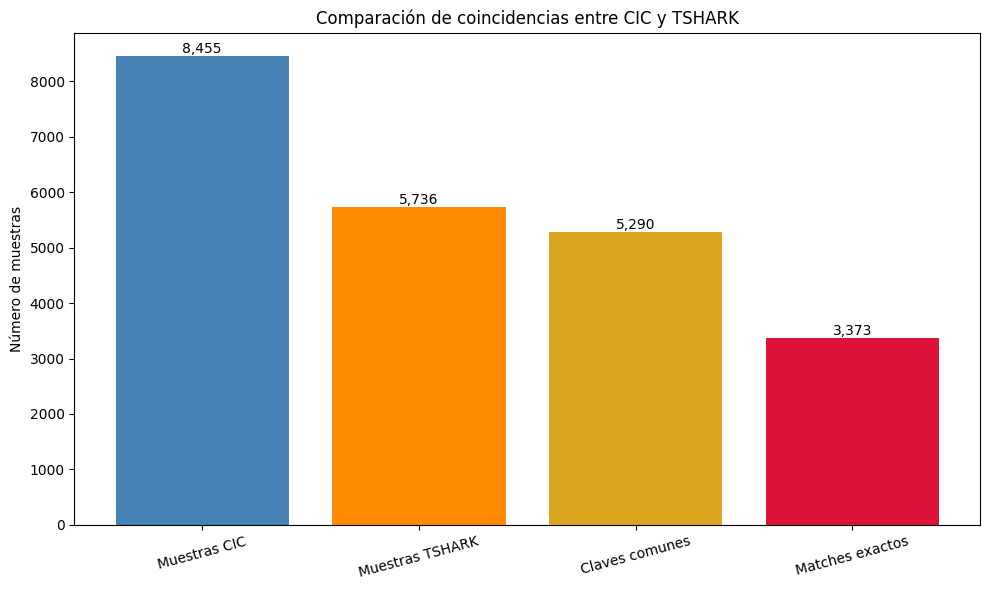


Porcentaje sobre CIC:    39.43%
Porcentaje sobre TSHARK: 58.8%


In [35]:
# ============================================================
# CELDA T6 - FILTRAR DATASETS FINALES Y GRÁFICA
# ============================================================
import matplotlib.pyplot as plt

df_cic_exactos_tshark = df_cic_base[df_cic_base[key_cic].isin(mejor_p)].copy()
df_tshark_exactos     = df_tshark_base[
    df_tshark_base[key_dir].isin(mejor_p) |
    df_tshark_base[key_inv].isin(mejor_p)
].copy()

print("=" * 55)
print("DATASETS FINALES")
print("=" * 55)
print(f"  Shape CIC exactos (Tshark):  {df_cic_exactos_tshark.shape}")
print(f"  Shape TSHARK exactos:        {df_tshark_exactos.shape}")
print()
print("Filas CIC que matchean:")
print(df_cic_exactos_tshark[[
    "Src IP","Src Port","Dst IP","Dst Port","Protocol","Timestamp","Flow Duration"
]].head(6).to_string(index=False))
print()
print("Sus pares en TSHARK:")
print(df_tshark_exactos[[
    "src_ip","src_port","dst_ip","dst_port","proto_num","start_utc2","flow_duration_us"
]].head(6).to_string(index=False))

# ── Gráfica ───────────────────────────────────────────────────
labels = ["Muestras CIC", "Muestras TSHARK", "Claves comunes", "Matches exactos"]
values = [len(claves_cic), len(claves_tshark_dir), len(comunes_tot), len(mejor_p)]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=["steelblue","darkorange","goldenrod","crimson"])
plt.title("Comparación de coincidencias entre CIC y TSHARK")
plt.ylabel("Número de muestras")
plt.xticks(rotation=15)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center", va="bottom"
    )

plt.tight_layout()
plt.show()

print(f"\nPorcentaje sobre CIC:    {round(len(mejor_p)/len(df_cic_base)*100,2)}%")
print(f"Porcentaje sobre TSHARK: {round(len(mejor_p)/len(df_tshark_base)*100,2)}%")

In [36]:
# ============================================================
# CELDA PREVIA - Recalcular variables para el resumen final
# ============================================================

# Clave base unificada CIC (5-tupla + segundo)
df_cic_base["key_base_unif"] = list(zip(
    df_cic_base["Src IP"].astype(str),
    df_cic_base["Src Port"].astype(str),
    df_cic_base["Dst IP"].astype(str),
    df_cic_base["Dst Port"].astype(str),
    df_cic_base["Protocol"].astype(str),
    df_cic_base["time_sec"].astype(str)
))
cic_keys = set(df_cic_base["key_base_unif"])

# Nemea
df_nemea_base["key_base_unif"] = list(zip(
    df_nemea_base["SRC_IP_norm"].astype(str),
    df_nemea_base["uint16 SRC_PORT"].astype(str),
    df_nemea_base["DST_IP_norm"].astype(str),
    df_nemea_base["uint16 DST_PORT"].astype(str),
    df_nemea_base["uint8 PROTOCOL"].astype(str),
    df_nemea_base["time_sec"].astype(str)
))
nemea_keys = set(df_nemea_base["key_base_unif"])

# Tstat (directa + invertida)
tstat_keys = set(df_tstat_base["key_base_dir"]) | set(df_tstat_base["key_base_inv"])

# Tshark (directa + invertida)
tshark_keys = set(df_tshark_base["key_base_dir"]) | set(df_tshark_base["key_base_inv"])

# Claves comunes con CIC
base_nemea  = cic_keys & nemea_keys
base_tstat  = cic_keys & tstat_keys
base_tshark = cic_keys & tshark_keys
base_4      = base_nemea & base_tstat & base_tshark

print(f"base_nemea:  {len(base_nemea)}")
print(f"base_tstat:  {len(base_tstat)}")
print(f"base_tshark: {len(base_tshark)}")
print(f"base_4:      {len(base_4)}")

base_nemea:  6301
base_tstat:  4718
base_tshark: 5290
base_4:      4047


RESUMEN FINAL — DictionaryBruteForce
  CIC    total:                     8,554
  Nemea  total:                     7,877
  Tstat  total:                     5,401
  Tshark total:                     5,736

  CIC ∩ Nemea  (5-tupla+segundo):   6,301
  CIC ∩ Tstat  (5-tupla+segundo):   4,718
  CIC ∩ Tshark (5-tupla+segundo):   5,290

  Nemea  matches exactos (ms):      3,712
  Tstat  matches exactos (ms):      1,211
  Tshark matches exactos (ms):      3,373

  COMUNES 4 HERRAMIENTAS:           4,047  ← flujos en todas
  % sobre CIC total:               47.31%


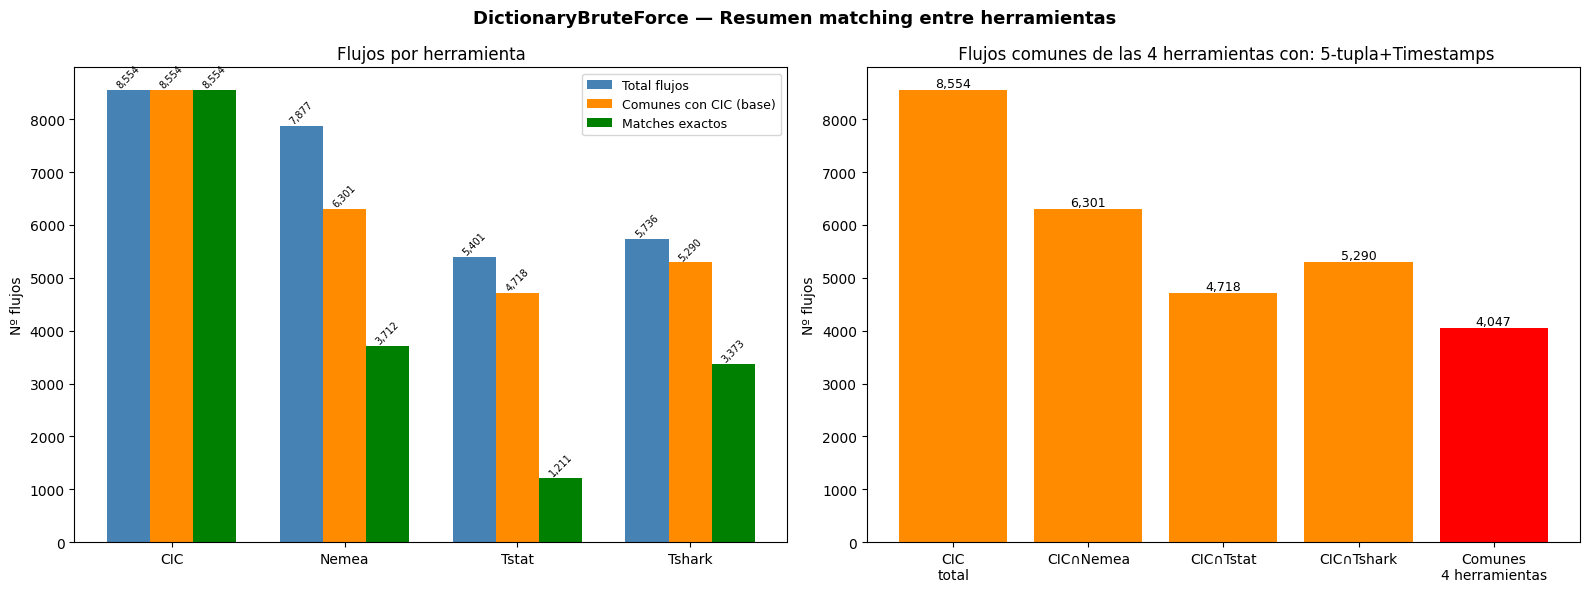

In [37]:
# ============================================================
# CELDA RESUMEN FINAL — DictionaryBruteForce
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# ── Tabla de datos ────────────────────────────────────────────
print("=" * 60)
print("RESUMEN FINAL — DictionaryBruteForce")
print("=" * 60)
print(f"  CIC    total:                    {len(df_cic_base):>6,}")
print(f"  Nemea  total:                    {len(df_nemea_base):>6,}")
print(f"  Tstat  total:                    {len(df_tstat_base):>6,}")
print(f"  Tshark total:                    {len(df_tshark_base):>6,}")
print()
print(f"  CIC ∩ Nemea  (5-tupla+segundo):  {len(base_nemea):>6,}")
print(f"  CIC ∩ Tstat  (5-tupla+segundo):  {len(base_tstat):>6,}")
print(f"  CIC ∩ Tshark (5-tupla+segundo):  {len(base_tshark):>6,}")
print()
print(f"  Nemea  matches exactos (ms):     {len(matches_exactos_ms):>6,}")
print(f"  Tstat  matches exactos (ms):     {len(df_cic_exactos):>6,}")
print(f"  Tshark matches exactos (ms):     {len(df_cic_exactos_tshark):>6,}")
print()
print(f"  COMUNES 4 HERRAMIENTAS:          {len(base_4):>6,}  ← flujos en todas")
print(f"  % sobre CIC total:               {round(len(base_4)/len(df_cic_base)*100,2)}%")

# ── Gráfica ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("DictionaryBruteForce — Resumen matching entre herramientas",
             fontsize=13, fontweight="bold")

# ── Gráfica 1: muestras totales vs comunes vs exactos ─────────
ax1 = axes[0]
herramientas = ["CIC", "Nemea", "Tstat", "Tshark"]
totales  = [len(df_cic_base), len(df_nemea_base),
            len(df_tstat_base), len(df_tshark_base)]
comunes  = [len(df_cic_base), len(base_nemea),
            len(base_tstat),  len(base_tshark)]
exactos  = [len(df_cic_base), len(matches_exactos_ms),
            len(df_cic_exactos), len(df_cic_exactos_tshark)]

x     = np.arange(len(herramientas))
width = 0.25

b1 = ax1.bar(x - width, totales, width, label="Total flujos",           color="steelblue")
b2 = ax1.bar(x,         comunes, width, label="Comunes con CIC (base)", color="darkorange")
b3 = ax1.bar(x + width, exactos, width, label="Matches exactos",        color="green")

ax1.set_title("Flujos por herramienta")
ax1.set_ylabel("Nº flujos")
ax1.set_xticks(x)
ax1.set_xticklabels(herramientas)
ax1.legend(fontsize=9)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h,
                 f"{h:,}", ha="center", va="bottom", fontsize=7, rotation=45)

# ── Gráfica 2: embudo hacia los comunes a las 4 ───────────────
ax2 = axes[1]
labels2 = ["CIC\ntotal", "CIC∩Nemea", "CIC∩Tstat", "CIC∩Tshark", "Comunes\n4 herramientas"]
values2 = [len(df_cic_base), len(base_nemea),
           len(base_tstat),  len(base_tshark), len(base_4)]
colors2 = ["darkorange", "darkorange", "darkorange", "darkorange", "red"]

bars2 = ax2.bar(labels2, values2, color=colors2)
ax2.set_title(" Flujos comunes de las 4 herramientas con: 5-tupla+Timestamps")
ax2.set_ylabel("Nº flujos")
for bar, val in zip(bars2, values2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{val:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [49]:
# ============================================================
# CELDA FINAL - EXTRAER LOS 4 CSVs COMPLETOS Y LIMPIOS
# ============================================================
from pathlib import Path

OUTPUT_DIR = Path("/home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/DictionaryBruteForce")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Columnas auxiliares que se añadieron durante el proceso
# y que NO son características originales de cada herramienta
COLS_EXTRA_CIC = ["archivo_origen","Timestamp_dt","time_sec",
                  "flow_key_base","key_base_unif","flow_key_base_tshark",
                  "key_base","key_p1","key_p2","key_tshark_p1","key_tshark_p2",
                  "match_key_exacta","match_key_exacta_ms","_en_base4","_key_tmp"]

COLS_EXTRA_NEMEA = ["TIME_FIRST_limpio","TIME_LAST_limpio",
                    "TIME_FIRST_dt","TIME_LAST_dt",
                    "TIME_FIRST_utc2","TIME_LAST_utc2",
                    "time_sec","key_base_unif","flow_key_base",
                    "match_key_exacta","match_key_exacta_ms",
                    "SRC_IP_norm","DST_IP_norm",
                    "flow_duration_us","flow_duration_ms",
                    "flow_key_base_dir","flow_key_base_inv"]

COLS_EXTRA_TSTAT = ["_key","key_base_dir","key_base_inv",
                    "time_sec","first_dt","last_dt",
                    "first_utc2","last_utc2",
                    "flow_key_base_dir","flow_key_base_inv",
                    "durat_ms","key_p1_dir","key_p1_inv",
                    "key_p2_dir","key_p2_inv","flow_duration_us","proto_num"]

COLS_EXTRA_TSHARK = ["_key","key_base_dir","key_base_inv",
                     "start_dt","start_utc2","time_sec",
                     "flow_duration_us","flow_duration_ms",
                     "key_p1_dir","key_p1_inv",
                     "key_p2_dir","key_p2_inv","proto_num"]

# ── CIC ──────────────────────────────────────────────────────
df_cic_4 = df_cic.loc[
    df_cic_base[df_cic_base["key_base_unif"].isin(base_4)].index
].copy()
df_cic_4["_key_tmp"] = df_cic_base.loc[df_cic_4.index, "key_base_unif"].values
df_cic_4["Flow Duration"] = pd.to_numeric(df_cic_4["Flow Duration"], errors="coerce")
df_cic_4 = df_cic_4.sort_values("Flow Duration", ascending=False)
df_cic_4 = df_cic_4.drop_duplicates(subset=["_key_tmp"], keep="first")
df_cic_4 = df_cic_4.drop(columns=COLS_EXTRA_CIC + ["_key_tmp"], errors="ignore")
df_cic_4 = df_cic_4.reset_index(drop=True)

# ── NEMEA ─────────────────────────────────────────────────────
df_nemea_4 = df_nemea.loc[
    df_nemea_base[df_nemea_base["key_base_unif"].isin(base_4)].index
].copy()
df_nemea_4 = df_nemea_4[~df_nemea_4.index.duplicated(keep="first")]
df_nemea_4 = df_nemea_4.drop(columns=COLS_EXTRA_NEMEA, errors="ignore")
df_nemea_4 = df_nemea_4.reset_index(drop=True)

# ── TSTAT ─────────────────────────────────────────────────────
df_tstat_base["_key"] = df_tstat_base["key_base_dir"].where(
    df_tstat_base["key_base_dir"].isin(base_4),
    df_tstat_base["key_base_inv"]
)
idx_tstat  = df_tstat_base[df_tstat_base["_key"].isin(base_4)].index
df_tstat_4 = df_tstat.loc[idx_tstat].copy()
df_tstat_4 = df_tstat_4[~df_tstat_4.index.duplicated(keep="first")]
df_tstat_4 = df_tstat_4.drop(columns=COLS_EXTRA_TSTAT, errors="ignore")
df_tstat_4 = df_tstat_4.reset_index(drop=True)

# ── TSHARK ────────────────────────────────────────────────────
df_tshark_base["_key"] = df_tshark_base["key_base_dir"].where(
    df_tshark_base["key_base_dir"].isin(base_4),
    df_tshark_base["key_base_inv"]
)
idx_tshark  = df_tshark_base[df_tshark_base["_key"].isin(base_4)].index
df_tshark_4 = df_tshark.loc[idx_tshark].copy()
df_tshark_4 = df_tshark_4[~df_tshark_4.index.duplicated(keep="first")]
df_tshark_4 = df_tshark_4.drop(columns=COLS_EXTRA_TSHARK, errors="ignore")
df_tshark_4 = df_tshark_4.reset_index(drop=True)

# ── Guardar ───────────────────────────────────────────────────
df_cic_4.to_csv(   OUTPUT_DIR / "CIC_comunes.csv",    index=False)
df_nemea_4.to_csv( OUTPUT_DIR / "Nemea_comunes.csv",  index=False)
df_tstat_4.to_csv( OUTPUT_DIR / "Tstat_comunes.csv",  index=False)
df_tshark_4.to_csv(OUTPUT_DIR / "Tshark_comunes.csv", index=False)

print("=" * 60)
print("RESULTADO FINAL — DictionaryBruteForce")
print("=" * 60)
print(f"  CIC:    {len(df_cic_4):>5} filas x {df_cic_4.shape[1]:>4} columnas")
print(f"  Nemea:  {len(df_nemea_4):>5} filas x {df_nemea_4.shape[1]:>4} columnas")
print(f"  Tstat:  {len(df_tstat_4):>5} filas x {df_tstat_4.shape[1]:>4} columnas")
print(f"  Tshark: {len(df_tshark_4):>5} filas x {df_tshark_4.shape[1]:>4} columnas")
print()
print("Columnas finales CIC:")
print(df_cic_4.columns.tolist())
print()
print("Columnas finales Nemea (últimas 5):")
print(df_nemea_4.columns[-5:].tolist())
print()
print("Columnas finales Tstat (últimas 5):")
print(df_tstat_4.columns[-5:].tolist())
print()
print("Columnas finales Tshark (últimas 5):")
print(df_tshark_4.columns[-5:].tolist())



RESULTADO FINAL — DictionaryBruteForce
  CIC:     4047 filas x   84 columnas
  Nemea:   4047 filas x  204 columnas
  Tstat:   4047 filas x  138 columnas
  Tshark:  4047 filas x   63 columnas

Columnas finales CIC:
['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bw

In [ ]:
# ============================================================
# VERIFICACIÓN CORRECTA — usando base_4 directamente
# ============================================================

# base_4 tiene las 4047 claves que son comunes a las 4 herramientas
# Solo hay que comprobar que cada CSV tiene exactamente esas claves

# Reconstruir key en cada CSV usando el mismo método que el matching

# CIC — Timestamp ya estaba convertido en df_cic_base con time_sec
# Lo más fiable es comparar los índices directamente
idx_cic_guardados    = set(df_cic_base[df_cic_base["key_base_unif"].isin(base_4)]
                           .drop_duplicates(subset=["key_base_unif"]).index)
idx_nemea_guardados  = set(df_nemea_base[df_nemea_base["key_base_unif"].isin(base_4)]
                           .drop_duplicates(subset=["key_base_unif"]).index)
idx_tstat_guardados  = set(df_tstat_base[df_tstat_base["_key"].isin(base_4)]
                           .drop_duplicates(subset=["_key"]).index)
idx_tshark_guardados = set(df_tshark_base[df_tshark_base["_key"].isin(base_4)]
                           .drop_duplicates(subset=["_key"]).index)

print("=" * 60)
print("VERIFICACIÓN — coincidencia con base_4")
print("=" * 60)
print(f"  base_4 claves:           {len(base_4)}")
print(f"  CIC filas guardadas:     {len(idx_cic_guardados)}")
print(f"  Nemea filas guardadas:   {len(idx_nemea_guardados)}")
print(f"  Tstat filas guardadas:   {len(idx_tstat_guardados)}")
print(f"  Tshark filas guardadas:  {len(idx_tshark_guardados)}")
print()

# Verificar que los 4 CSVs tienen exactamente 4047 filas
todos_ok = all([
    len(df_cic_4)    == len(base_4),
    len(df_nemea_4)  == len(base_4),
    len(df_tstat_4)  == len(base_4),
    len(df_tshark_4) == len(base_4),
    len(idx_cic_guardados)    == len(base_4),
    len(idx_nemea_guardados)  == len(base_4),
    len(idx_tstat_guardados)  == len(base_4),
    len(idx_tshark_guardados) == len(base_4),
])

if todos_ok:
    print("  ✓ VERIFICACIÓN CORRECTA")
    print(f"    Los 4 CSVs tienen exactamente {len(base_4)} flujos")
    print("    cada uno con las características de su herramienta")
    print("    y todos corresponden a las mismas claves de base_4")
else:
    print("  ✗ Algún CSV no tiene exactamente 4047 filas → revisar")

VERIFICACIÓN — coincidencia con base_4
  base_4 claves:           4047
  CIC filas guardadas:     4047
  Nemea filas guardadas:   4047
  Tstat filas guardadas:   4047
  Tshark filas guardadas:  4047

  ✓ VERIFICACIÓN CORRECTA
    Los 4 CSVs tienen exactamente 4047 flujos
    cada uno con las características de su herramienta
    y todos corresponden a las mismas claves de base_4
